# Label Analysis — Data-Driven Tier Selection and Partitioning Validation

This notebook performs a **data-driven** analysis of the label proxy for CircuitNet-N28 partitioning
and validates all label/quantity-based NIID-Bench strategies.

## Structure

| Section | Content |
|---------|--------|
| A | Violation-rate distribution |
| B | Fixed cutoffs analysis (0/2/8/20%) |
| C | Data-driven cutoffs: quartile vs hybrid vs fixed |
| D | Design–tier correlation (Cramér's V, ANOVA) |
| E | Option D: multi-statistic proxy (rate + hotspot count) |
| F | Option E: natural skew from design-based partitioning |
| G | Dirichlet parameter sweep |
| H | Cutoff selection summary and data-driven recommendation |
| **I** | **Partitioning helpers and working tier selection** |
| **J** | **Strategy 1 — IID (label baseline)** |
| **K** | **Strategy 2 — Quantity-based label imbalance** |
| **L** | **Strategy 3 — Distribution-based label imbalance (Dirichlet)** |
| **M** | **Strategy 6 — Quantity skew** |
| **N** | **Cross-strategy comparison (all 6 strategies)** |

In [1]:
import os
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as mcm
from scipy import stats as scipy_stats
from scipy.stats import entropy as scipy_entropy

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.titlesize': 11,
    'axes.grid': True,
    'grid.color': 'white',
    'grid.linewidth': 0.8,
    'axes.facecolor': '#f5f5f5',
    'figure.facecolor': 'white',
})

sys.path.insert(0, os.path.abspath('.'))
from partitioning import LabelTierAssigner

VIOLATION_THRESHOLD = 0.1
FEATURE_DIR = '../../drc_prediction/training_set/feature/'
LABEL_DIR   = '../../drc_prediction/training_set/label/'
print('Imports OK.')

Imports OK.


## Data Loading

Load real CircuitNet-N28 label files or fall back to a statistically realistic mock.  
The mock reproduces the known property from FEATURES_DESCRIPTION §6.7: per-sample violation rate is strongly right-skewed.

In [2]:
def parse_sample_name(filename: str) -> dict:
    basename = filename.replace('.npy', '')
    parts = basename.split('-')
    if parts[0].isdigit():
        parts = parts[1:]
    if len(parts) >= 2 and len(parts[1]) == 1 and parts[1].isalpha():
        design_name = parts[0] + '-' + parts[1]
        rest = parts[2:]
    else:
        design_name = parts[0]
        rest = parts[1:]
    if len(rest) < 6:
        raise ValueError(f'Cannot parse: {filename}')
    return {
        'design_name':     design_name,
        'macro_count':     rest[0],
        'clock_ns':        float(rest[1][1:]),
        'utilization':     float(rest[2][1:]),
        'macro_placement': rest[3][1:],
        'power_mesh':      rest[4][1:],
        'filler_insertion':rest[5][1:],
        'filename':        filename,
    }


feature_exists = os.path.isdir(FEATURE_DIR)
label_exists   = os.path.isdir(LABEL_DIR)

if feature_exists and label_exists:
    files = [f for f in os.listdir(FEATURE_DIR) if f.endswith('.npy')]
    print(f'Real dataset: {len(files)} feature files found.')
    records = []
    for fname in files:
        try:
            records.append(parse_sample_name(fname))
        except Exception as e:
            print(f'  Skipping {fname}: {e}')
    df_meta = pd.DataFrame(records)

    print('Loading label .npy files...')
    rates = []
    for fname in df_meta['filename']:
        lpath = os.path.join(LABEL_DIR, fname)
        try:
            arr = np.load(lpath)
            rates.append(float(np.mean(arr >= VIOLATION_THRESHOLD)))
        except Exception:
            rates.append(float('nan'))
    df_meta['violation_rate'] = rates
    df_meta = df_meta.dropna(subset=['violation_rate']).reset_index(drop=True)
    DATASET_SOURCE = 'real'

else:
    print('Dataset not found — generating realistic mock (heavy right-skew).')
    rng = np.random.default_rng(42)
    N = 10242
    DESIGNS = ['RISCY-a','RISCY-b','RISCY-c','RISCY-d','RISCY-e','RISCY-f']
    CLOCKS  = [1.0, 1.5, 2.0, 2.5, 3.0, 3.3]
    UTILS   = [0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

    design_baseline = {
        'RISCY-a': 0.010, 'RISCY-b': 0.025, 'RISCY-c': 0.005,
        'RISCY-d': 0.040, 'RISCY-e': 0.015, 'RISCY-f': 0.030,
    }
    records = []
    violation_rates = []
    for _ in range(N):
        d  = rng.choice(DESIGNS)
        mc = rng.choice(['1','2','3','4'])
        c  = rng.choice(CLOCKS)
        u  = rng.choice(UTILS)
        mp = rng.choice(['1','2','3'])
        pm = rng.choice(['1','2'])
        fi = rng.choice(['0','1'])
        u_eff  = 0.18 * ((u - 0.4) / 0.5) ** 2
        c_eff  = 0.04 * (1.0 - c / 3.3)
        base   = design_baseline[d] + u_eff + c_eff
        noise  = rng.beta(0.5, 5.0) * 0.12
        rate   = float(np.clip(base + noise, 0.0, 1.0))
        fname  = f'{d}-{mc}-c{c}-u{u}-m{mp}-p{pm}-f{fi}.npy'
        records.append({
            'design_name':d,'macro_count':mc,'clock_ns':float(c),
            'utilization':float(u),'macro_placement':mp,
            'power_mesh':pm,'filler_insertion':fi,'filename':fname,
        })
        violation_rates.append(rate)

    df_meta = pd.DataFrame(records)
    df_meta['violation_rate'] = violation_rates
    DATASET_SOURCE = 'mock'

print(f'Source: {DATASET_SOURCE}  |  Samples: {len(df_meta)}')
print(df_meta['violation_rate'].describe().to_string())

Dataset not found — generating realistic mock (heavy right-skew).
Source: mock  |  Samples: 10242
count    10242.000000
mean         0.110781
std          0.067159
min          0.005002
25%          0.055119
50%          0.093604
75%          0.159592
max          0.304116


---
## Section A — Violation-Rate Distribution

Percentiles of violation_rate:
  P01: 0.0142
  P05: 0.0262
  P10: 0.0355
  P25: 0.0551
  P50: 0.0936
  P75: 0.1596
  P90: 0.2185
  P95: 0.2336
  P99: 0.2586


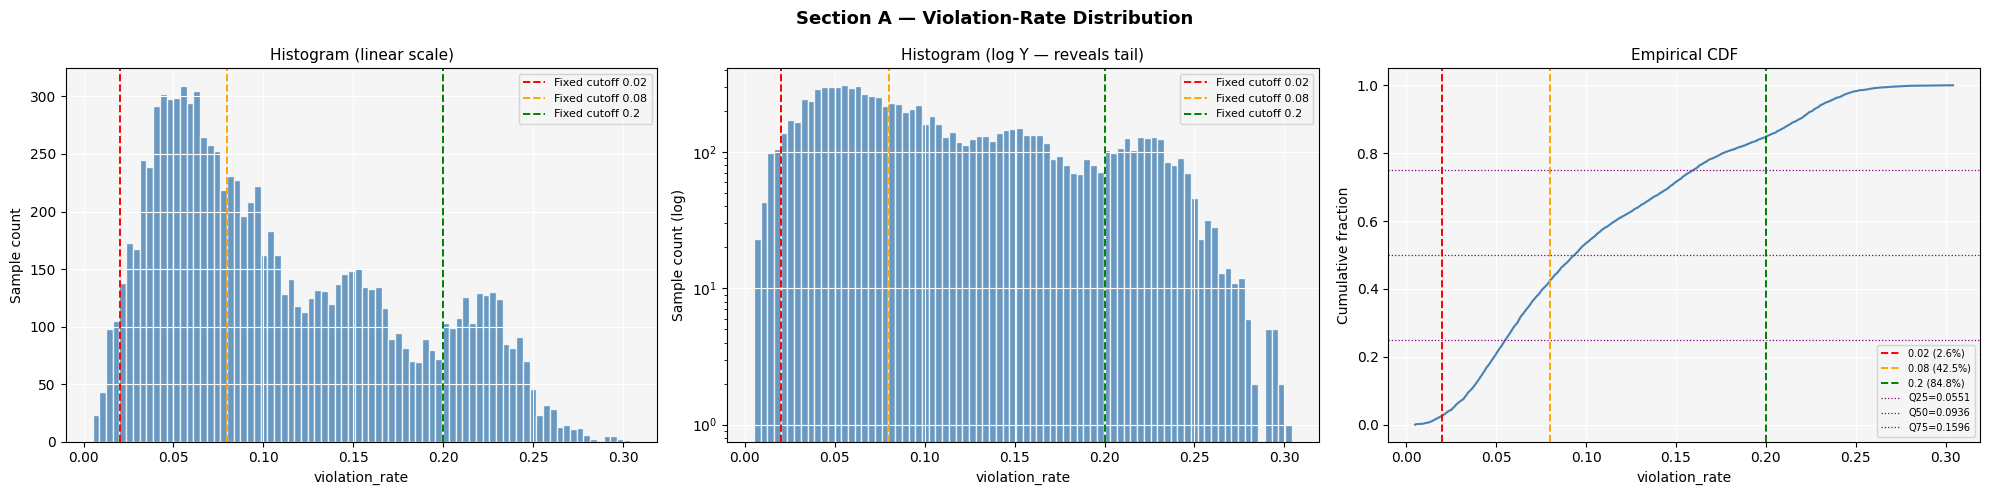

In [3]:
vr = df_meta['violation_rate'].values

pctls = [1, 5, 10, 25, 50, 75, 90, 95, 99]
pctl_vals = np.percentile(vr, pctls)
print('Percentiles of violation_rate:')
for p, v in zip(pctls, pctl_vals):
    print(f'  P{p:02d}: {v:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Section A — Violation-Rate Distribution', fontsize=13, fontweight='bold')

ax = axes[0]
ax.hist(vr, bins=80, color='steelblue', alpha=0.8, edgecolor='white')
for bnd, col in zip([0.02, 0.08, 0.20], ['red','orange','green']):
    ax.axvline(bnd, color=col, linestyle='--', linewidth=1.4, label=f'Fixed cutoff {bnd}')
ax.set_title('Histogram (linear scale)')
ax.set_xlabel('violation_rate')
ax.set_ylabel('Sample count')
ax.legend(fontsize=8)

ax = axes[1]
ax.hist(vr, bins=80, color='steelblue', alpha=0.8, edgecolor='white')
ax.set_yscale('log')
for bnd, col in zip([0.02, 0.08, 0.20], ['red','orange','green']):
    ax.axvline(bnd, color=col, linestyle='--', linewidth=1.4, label=f'Fixed cutoff {bnd}')
ax.set_title('Histogram (log Y — reveals tail)')
ax.set_xlabel('violation_rate')
ax.set_ylabel('Sample count (log)')
ax.legend(fontsize=8)

ax = axes[2]
sorted_vr = np.sort(vr)
cdf = np.arange(1, len(sorted_vr)+1) / len(sorted_vr)
ax.plot(sorted_vr, cdf, color='steelblue', linewidth=1.5)
for bnd, col in zip([0.02, 0.08, 0.20], ['red','orange','green']):
    pct_below = float(np.mean(vr < bnd)) * 100
    ax.axvline(bnd, color=col, linestyle='--', linewidth=1.4,
               label=f'{bnd} ({pct_below:.1f}%)')
for q, qv in zip([25,50,75], np.percentile(vr, [25,50,75])):
    ax.axhline(q/100, color='purple', linestyle=':', linewidth=0.9,
               label=f'Q{q}={qv:.4f}')
ax.set_title('Empirical CDF')
ax.set_xlabel('violation_rate')
ax.set_ylabel('Cumulative fraction')
ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

---
## Section B — Fixed Cutoffs Analysis (0 / 2% / 8% / 20%)

Fixed cutoffs tier distribution:
  Tier 0 [clean (0-2%)]:   269 samples (2.6%)
  Tier 1 [low (2-8%)]:  4082 samples (39.9%)
  Tier 2 [medium (8-20%)]:  4338 samples (42.4%)
  Tier 3 [high (20-100%)]:  1553 samples (15.2%)

Balance ratio (min/max): 0.062
Imbalance factor (max/min): 16.1x


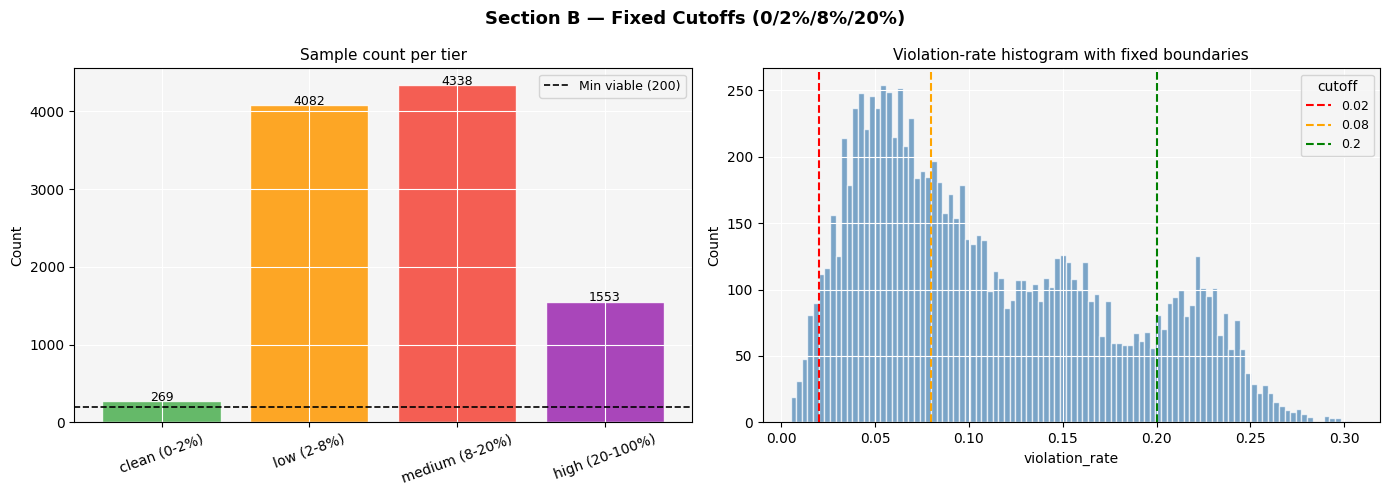

In [4]:
FIXED_BOUNDARIES = [0.0, 0.02, 0.08, 0.20, 1.01]
FIXED_NAMES = ['clean (0-2%)', 'low (2-8%)', 'medium (8-20%)', 'high (20-100%)']
MIN_VIABLE_SAMPLES = 200

assigner_fixed = LabelTierAssigner(threshold=VIOLATION_THRESHOLD, boundaries=FIXED_BOUNDARIES)
df_meta['tier_fixed'] = df_meta['violation_rate'].apply(assigner_fixed.assign_tier)

counts_fixed = df_meta['tier_fixed'].value_counts().sort_index()
pcts_fixed   = counts_fixed / len(df_meta) * 100

print('Fixed cutoffs tier distribution:')
for t, name in enumerate(FIXED_NAMES):
    cnt = counts_fixed.get(t, 0)
    pct = pcts_fixed.get(t, 0)
    flag = '  *** TOO SMALL ***' if cnt < MIN_VIABLE_SAMPLES else ''
    print(f'  Tier {t} [{name}]: {cnt:5d} samples ({pct:.1f}%){flag}')

print(f'\nBalance ratio (min/max): {counts_fixed.min()/counts_fixed.max():.3f}')
print(f'Imbalance factor (max/min): {counts_fixed.max()/counts_fixed.min():.1f}x')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Section B — Fixed Cutoffs (0/2%/8%/20%)', fontsize=13, fontweight='bold')

colors_fixed = ['#4caf50','#ff9800','#f44336','#9c27b0']

ax = axes[0]
bars = ax.bar(FIXED_NAMES, [counts_fixed.get(t,0) for t in range(4)],
              color=colors_fixed, alpha=0.85, edgecolor='white')
ax.axhline(MIN_VIABLE_SAMPLES, color='black', linestyle='--', linewidth=1.2,
           label=f'Min viable ({MIN_VIABLE_SAMPLES})')
ax.set_title('Sample count per tier')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=20)
ax.legend(fontsize=9)
for bar, cnt in zip(bars, [counts_fixed.get(t,0) for t in range(4)]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
            f'{cnt}', ha='center', fontsize=9)

ax = axes[1]
ax.hist(vr, bins=100, color='steelblue', alpha=0.7, edgecolor='white')
for bnd, col in zip(FIXED_BOUNDARIES[1:-1], ['red','orange','green']):
    ax.axvline(bnd, color=col, linestyle='--', linewidth=1.5, label=f'{bnd}')
ax.set_title('Violation-rate histogram with fixed boundaries')
ax.set_xlabel('violation_rate')
ax.set_ylabel('Count')
ax.legend(fontsize=9, title='cutoff')

plt.tight_layout()
plt.show()

---
## Section C — Data-Driven Cutoffs: Quartile vs Hybrid vs Fixed

Quartile boundaries: ['0.0000', '0.0551', '0.0936', '0.1596', '1.0100']
Hybrid boundaries:   ['0.0000', '0.0200', '0.0681', '0.1403', '1.0100']

Cutoff scheme comparison:
                      Tier 0  Tier 1  Tier 2  Tier 3  Min tier  Max/Min ratio  Balance (min/max)
Scheme                                                                                          
Fixed (0/2/8/20%)        269    4082    4338    1553       269           16.1              0.062
Quartile Q25/50/75      2561    2560    2560    2561      2560            1.0              1.000
Hybrid (2%+tertiles)     269    3291    3391    3291       269           12.6              0.079


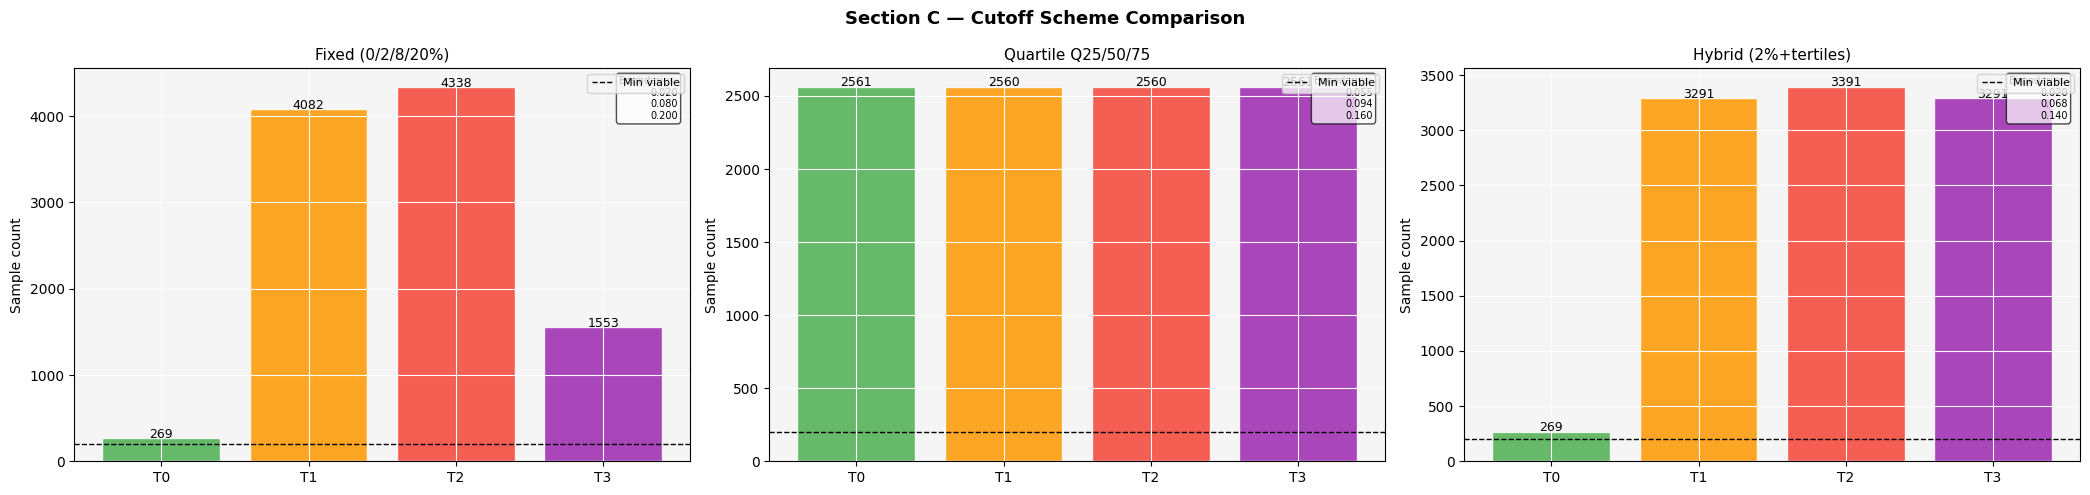

In [5]:
q25, q50, q75 = np.percentile(vr, [25, 50, 75])
QUARTILE_BOUNDARIES = [0.0, float(q25), float(q50), float(q75), 1.01]
print(f'Quartile boundaries: {[f"{b:.4f}" for b in QUARTILE_BOUNDARIES]}')

vr_above_clean = vr[vr >= 0.02]
h_33, h_67 = np.percentile(vr_above_clean, [33, 67])
HYBRID_BOUNDARIES = [0.0, 0.02, float(h_33), float(h_67), 1.01]
print(f'Hybrid boundaries:   {[f"{b:.4f}" for b in HYBRID_BOUNDARIES]}')

assigner_qrt = LabelTierAssigner(threshold=VIOLATION_THRESHOLD, boundaries=QUARTILE_BOUNDARIES)
assigner_hyb = LabelTierAssigner(threshold=VIOLATION_THRESHOLD, boundaries=HYBRID_BOUNDARIES)
df_meta['tier_quartile'] = df_meta['violation_rate'].apply(assigner_qrt.assign_tier)
df_meta['tier_hybrid']   = df_meta['violation_rate'].apply(assigner_hyb.assign_tier)

schemes = [
    ('Fixed (0/2/8/20%)',     'tier_fixed',    FIXED_BOUNDARIES,    FIXED_NAMES),
    ('Quartile Q25/50/75',    'tier_quartile', QUARTILE_BOUNDARIES,
     [f'T{i}: [{QUARTILE_BOUNDARIES[i]:.3f},{QUARTILE_BOUNDARIES[i+1]:.3f})' for i in range(4)]),
    ('Hybrid (2%+tertiles)',  'tier_hybrid',   HYBRID_BOUNDARIES,
     [f'T{i}: [{HYBRID_BOUNDARIES[i]:.3f},{HYBRID_BOUNDARIES[i+1]:.3f})' for i in range(4)]),
]

rows = []
for scheme_name, col, bnds, _ in schemes:
    cnts = df_meta[col].value_counts().sort_index()
    rows.append({
        'Scheme': scheme_name,
        'Tier 0': int(cnts.get(0,0)), 'Tier 1': int(cnts.get(1,0)),
        'Tier 2': int(cnts.get(2,0)), 'Tier 3': int(cnts.get(3,0)),
        'Min tier': int(cnts.min()),
        'Max/Min ratio': round(float(cnts.max()/cnts.min()), 1),
        'Balance (min/max)': round(float(cnts.min()/cnts.max()), 3),
    })

cmp_df = pd.DataFrame(rows).set_index('Scheme')
print('\nCutoff scheme comparison:')
print(cmp_df.to_string())

fig, axes = plt.subplots(1, 3, figsize=(21, 5))
fig.suptitle('Section C — Cutoff Scheme Comparison', fontsize=13, fontweight='bold')
palette = ['#4caf50','#ff9800','#f44336','#9c27b0']

for ax, (scheme_name, col, bnds, _) in zip(axes, schemes):
    cnts = df_meta[col].value_counts().sort_index()
    bars = ax.bar(range(4), [cnts.get(t,0) for t in range(4)],
                  color=palette, alpha=0.85, edgecolor='white')
    ax.set_xticks(range(4))
    ax.set_xticklabels([f'T{t}' for t in range(4)])
    ax.set_title(scheme_name)
    ax.set_ylabel('Sample count')
    ax.axhline(MIN_VIABLE_SAMPLES, color='black', linestyle='--',
               linewidth=1.0, label='Min viable')
    ax.legend(fontsize=8)
    for bar, cnt in zip(bars, [cnts.get(t,0) for t in range(4)]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                f'{cnt}', ha='center', fontsize=9)
    ax.text(0.98, 0.98,
            'Boundaries:\n' + '\n'.join([f'{b:.3f}' for b in bnds[1:-1]]),
            transform=ax.transAxes, fontsize=7, va='top', ha='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()

---
## Section D — Design–Tier Correlation

In [6]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2, _, _, _ = chi2_contingency(ct)
    n = ct.values.sum()
    k = min(ct.shape) - 1
    return float(np.sqrt(chi2 / (n * k))) if k > 0 else 0.0


designs = sorted(df_meta['design_name'].unique())

print('Cramér\'s V (design_name ↔ tier) — 0=independent, 1=perfect:')
for scheme_name, col, *_ in schemes:
    v = cramers_v(df_meta['design_name'], df_meta[col])
    print(f'  {scheme_name:<30s}: V = {v:.4f}')

groups = [df_meta.loc[df_meta['design_name']==d,'violation_rate'].values for d in designs]
stat, pval = scipy_stats.kruskal(*groups)
print(f'\nKruskal-Wallis H={stat:.2f}, p={pval:.2e}')

print('\nViolation rate per design:')
print(df_meta.groupby('design_name')['violation_rate']
      .agg(['mean','median','std','min','max']).round(4).to_string())

Cramér's V (design_name ↔ tier) — 0=independent, 1=perfect:
  Fixed (0/2/8/20%)             : V = 0.1331
  Quartile Q25/50/75            : V = 0.1485
  Hybrid (2%+tertiles)          : V = 0.1533

Kruskal-Wallis H=460.71, p=2.40e-97

Violation rate per design:
               mean  median     std     min     max
design_name                                        
RISCY-a      0.1018  0.0841  0.0676  0.0101  0.2895
RISCY-b      0.1140  0.0944  0.0659  0.0250  0.2930
RISCY-c      0.0942  0.0776  0.0662  0.0050  0.2665
RISCY-d      0.1312  0.1145  0.0657  0.0400  0.3041
RISCY-e      0.1044  0.0858  0.0659  0.0150  0.2921
RISCY-f      0.1197  0.1022  0.0649  0.0302  0.2900


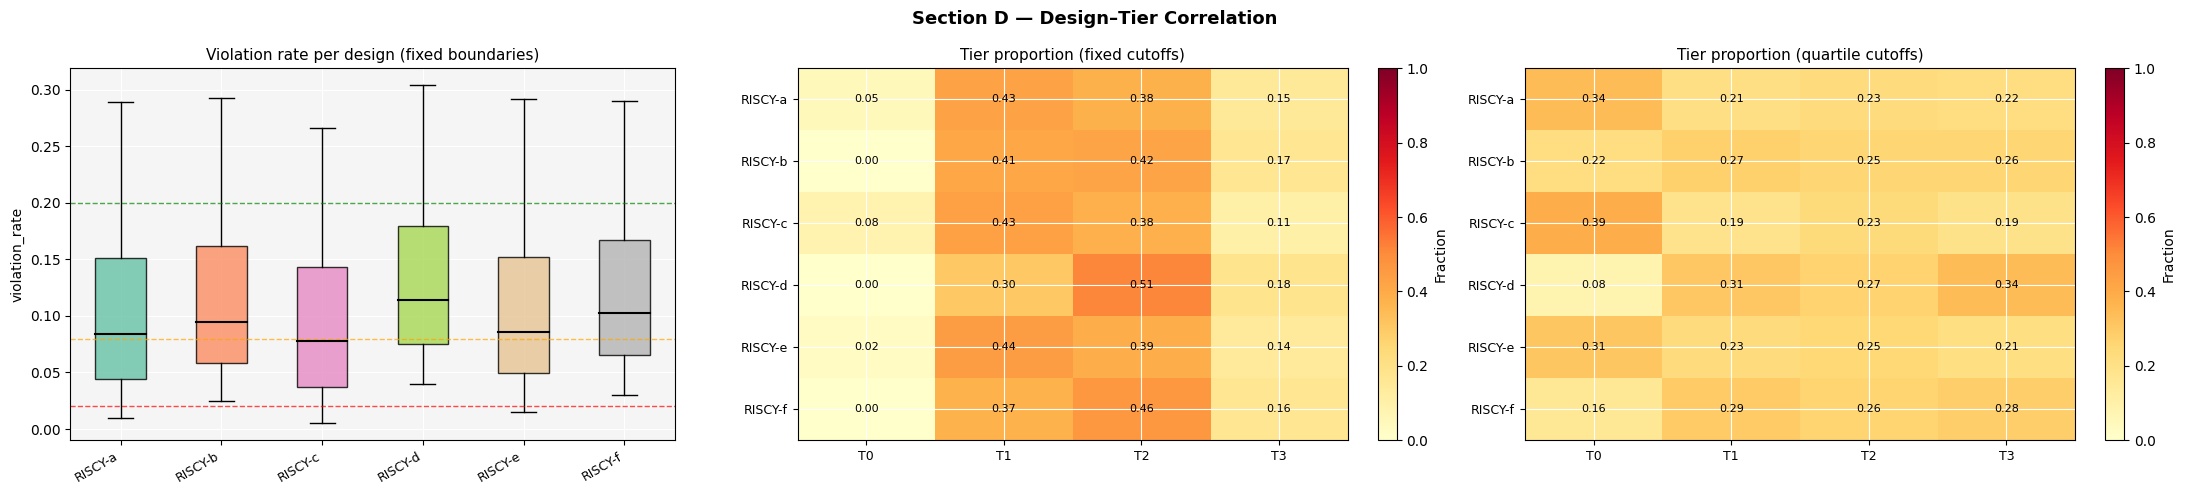

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(22, 5))
fig.suptitle('Section D — Design–Tier Correlation', fontsize=13, fontweight='bold')

cmap_d = mcm.get_cmap('Set2', len(designs))

ax = axes[0]
data_per_design = [df_meta.loc[df_meta['design_name']==d,'violation_rate'].values for d in designs]
bp = ax.boxplot(data_per_design, patch_artist=True, notch=False,
                medianprops={'color':'black','linewidth':1.5},
                flierprops={'marker':'.','markersize':2,'alpha':0.3})
for patch, i in zip(bp['boxes'], range(len(designs))):
    patch.set_facecolor(cmap_d(i))
    patch.set_alpha(0.8)
for bnd, col in zip(FIXED_BOUNDARIES[1:-1], ['red','orange','green']):
    ax.axhline(bnd, color=col, linestyle='--', linewidth=1.0, alpha=0.7)
ax.set_xticks(range(1, len(designs)+1))
ax.set_xticklabels(designs, rotation=30, ha='right', fontsize=9)
ax.set_title('Violation rate per design (fixed boundaries)')
ax.set_ylabel('violation_rate')

for ax_idx, (ax, tier_col, title) in enumerate([
    (axes[1], 'tier_fixed',    'Tier proportion (fixed cutoffs)'),
    (axes[2], 'tier_quartile', 'Tier proportion (quartile cutoffs)'),
]):
    mat = np.zeros((len(designs), 4))
    for i, d in enumerate(designs):
        sub = df_meta.loc[df_meta['design_name']==d, tier_col]
        for t in range(4):
            mat[i, t] = (sub == t).sum() / len(sub)
    im = ax.imshow(mat, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
    for r in range(len(designs)):
        for c in range(4):
            val = mat[r,c]
            ax.text(c, r, f'{val:.2f}', ha='center', va='center',
                    fontsize=8, color='white' if val > 0.55 else 'black')
    ax.set_xticks(range(4))
    ax.set_xticklabels([f'T{t}' for t in range(4)], fontsize=9)
    ax.set_yticks(range(len(designs)))
    ax.set_yticklabels(designs, fontsize=9)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.04, label='Fraction')

plt.tight_layout()
plt.show()

---
## Section E — Option D: Multi-Statistic Proxy (Rate + Hotspot Count)

Pearson r  = 0.9434  (p=0.00e+00)
Spearman r = 0.9465  (p=0.00e+00)


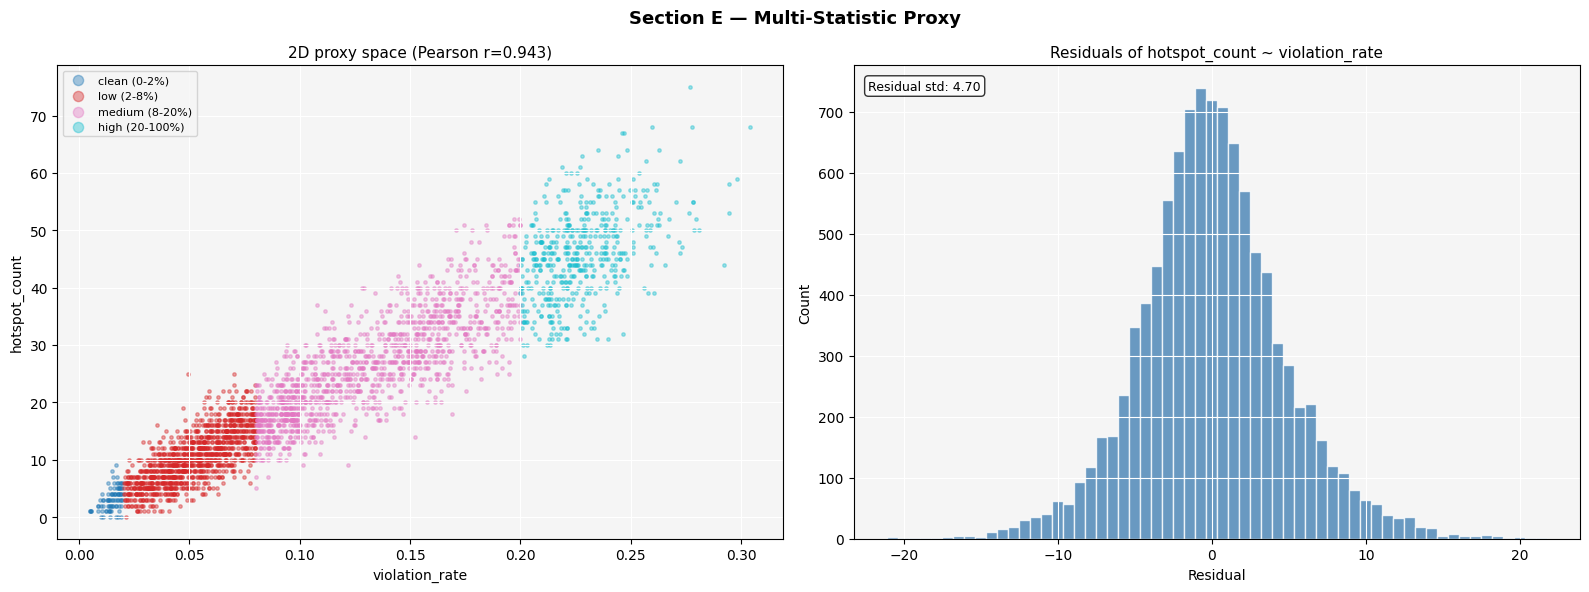

→ HIGH correlation: violation_rate alone is sufficient. Option D adds no value.


In [8]:
if DATASET_SOURCE == 'real':
    from scipy.ndimage import label as nd_label
    hotspot_counts = []
    for fname in df_meta['filename']:
        lpath = os.path.join(LABEL_DIR, fname)
        try:
            arr = np.load(lpath)
            binary = (arr >= VIOLATION_THRESHOLD).astype(int)
            _, n_clusters = nd_label(binary)
            hotspot_counts.append(float(n_clusters))
        except Exception:
            hotspot_counts.append(float('nan'))
    df_meta['hotspot_count'] = hotspot_counts
else:
    rng_hs = np.random.default_rng(99)
    lam = np.clip(df_meta['violation_rate'].values * 200, 0.5, 500.0)
    df_meta['hotspot_count'] = rng_hs.poisson(lam).astype(float)

df_meta = df_meta.dropna(subset=['hotspot_count'])

r, pval = scipy_stats.pearsonr(df_meta['violation_rate'], df_meta['hotspot_count'])
r_s, pval_s = scipy_stats.spearmanr(df_meta['violation_rate'], df_meta['hotspot_count'])
print(f'Pearson r  = {r:.4f}  (p={pval:.2e})')
print(f'Spearman r = {r_s:.4f}  (p={pval_s:.2e})')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Section E — Multi-Statistic Proxy', fontsize=13, fontweight='bold')

ax = axes[0]
n_plot = min(3000, len(df_meta))
sample = df_meta.sample(n_plot, random_state=0)
cmap_t = mcm.get_cmap('tab10', 4)
for t in range(4):
    sub = sample[sample['tier_fixed'] == t]
    ax.scatter(sub['violation_rate'], sub['hotspot_count'],
               s=6, alpha=0.4, color=cmap_t(t), label=FIXED_NAMES[t])
ax.set_xlabel('violation_rate')
ax.set_ylabel('hotspot_count')
ax.set_title(f'2D proxy space (Pearson r={r:.3f})')
ax.legend(fontsize=8, markerscale=3)

ax = axes[1]
X = df_meta['violation_rate'].values
Y = df_meta['hotspot_count'].values
coef = np.polyfit(X, Y, 1)
residuals = Y - np.polyval(coef, X)
ax.hist(residuals, bins=60, color='steelblue', alpha=0.8, edgecolor='white')
ax.set_title('Residuals of hotspot_count ~ violation_rate')
ax.set_xlabel('Residual')
ax.set_ylabel('Count')
ax.text(0.02, 0.97, f'Residual std: {residuals.std():.2f}',
        transform=ax.transAxes, fontsize=9, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

if abs(r) > 0.90:
    print('→ HIGH correlation: violation_rate alone is sufficient. Option D adds no value.')
elif abs(r) > 0.70:
    print('→ MODERATE: hotspot_count is partially informative.')
else:
    print('→ LOW correlation: 2D proxy recommended.')

---
## Section F — Option E: Natural Skew from Design-Based Partitioning

Design-based partition sizes:
  RISCY-a:  1706  [T0:82 T1:731 T2:641 T3:252]
  RISCY-b:  1727  [T0:0 T1:710 T2:727 T3:290]
  RISCY-c:  1730  [T0:145 T1:747 T2:656 T3:182]
  RISCY-d:  1708  [T0:0 T1:519 T2:878 T3:311]
  RISCY-e:  1720  [T0:42 T1:762 T2:669 T3:247]
  RISCY-f:  1651  [T0:0 T1:613 T2:767 T3:271]

Global tier entropy: 1.1121
Label entropy MAD (design-based): 0.0662


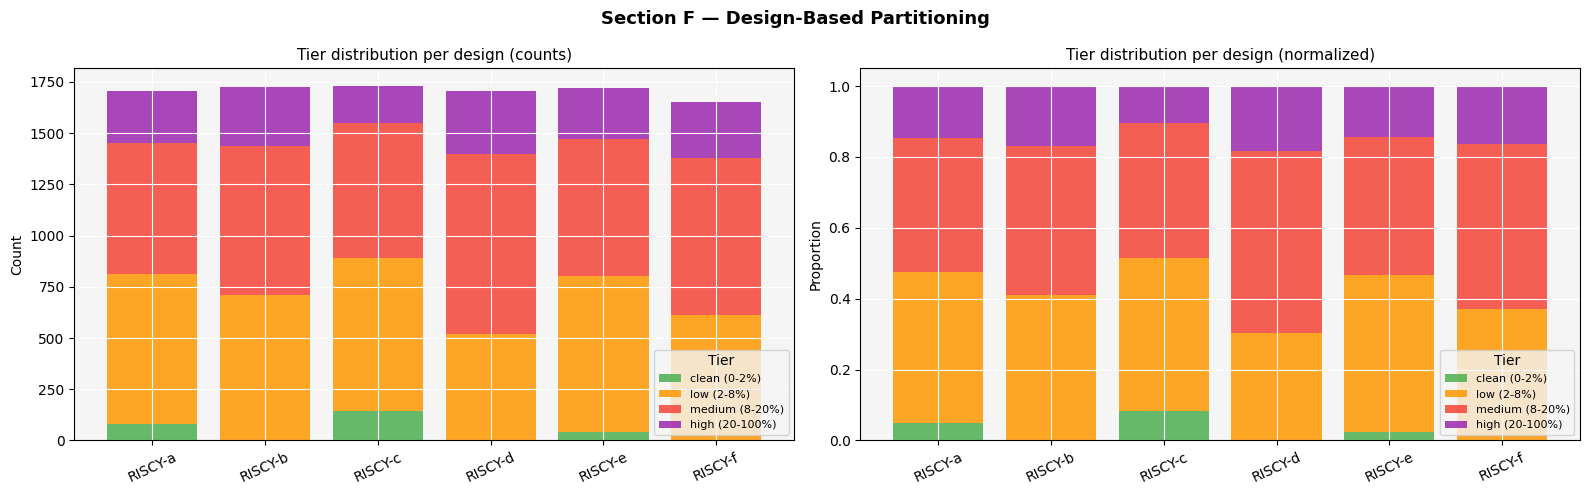

In [9]:
design_partitions = [df_meta[df_meta['design_name']==d].reset_index(drop=True)
                     for d in designs]

print('Design-based partition sizes:')
for d, p in zip(designs, design_partitions):
    td = p['tier_fixed'].value_counts().sort_index()
    print(f'  {d}: {len(p):5d}  [{" ".join(f"T{t}:{td.get(t,0)}" for t in range(4))}]')

global_tier_counts = df_meta['tier_fixed'].value_counts().sort_index().values
global_entropy = scipy_entropy(global_tier_counts)
design_entropies = []
for p in design_partitions:
    cnts = p['tier_fixed'].value_counts().reindex(range(4), fill_value=0).values
    design_entropies.append(scipy_entropy(cnts))
design_entropy_mad = float(np.mean(np.abs(np.array(design_entropies) - global_entropy)))
print(f'\nGlobal tier entropy: {global_entropy:.4f}')
print(f'Label entropy MAD (design-based): {design_entropy_mad:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Section F — Design-Based Partitioning', fontsize=13, fontweight='bold')
palette_t = ['#4caf50','#ff9800','#f44336','#9c27b0']

for ax_idx, (ax, norm) in enumerate([(axes[0], False), (axes[1], True)]):
    bottom = np.zeros(len(designs))
    for t in range(4):
        vals = np.array([
            (p['tier_fixed']==t).sum() / (len(p) if norm else 1)
            for p in design_partitions
        ])
        ax.bar(designs, vals, bottom=bottom, color=palette_t[t],
               label=FIXED_NAMES[t], alpha=0.85)
        bottom += vals
    ax.set_title('Tier distribution per design ' + ('(normalized)' if norm else '(counts)'))
    ax.set_ylabel('Proportion' if norm else 'Count')
    ax.tick_params(axis='x', rotation=25)
    ax.legend(title='Tier', fontsize=8)

plt.tight_layout()
plt.show()

---
## Section G — Dirichlet Parameter Sweep

In [10]:
from partitioning import DirichletLabelPartitioner

N_PARTIES = 6
ALPHAS = [0.05, 0.1, 0.3, 0.5, 1.0, 5.0]

results = []
for tier_col_g, scheme_label in [('tier_fixed','Fixed'), ('tier_quartile','Quartile')]:
    df_g = df_meta.copy()
    df_g['tier'] = df_g[tier_col_g]
    for alpha in ALPHAS:
        try:
            parts = DirichletLabelPartitioner(
                n_partitions=N_PARTIES, alpha=alpha, label_col='tier', seed=42
            ).partition(df_g)
            sizes = np.array([len(p) for p in parts])
            ents  = np.array([
                scipy_entropy(p['tier'].value_counts().reindex(range(4), fill_value=0).values)
                for p in parts
            ])
            results.append({
                'Scheme': scheme_label, 'α': alpha,
                'Min size': int(sizes.min()), 'Max size': int(sizes.max()),
                'Size std': round(float(sizes.std()), 0),
                'Entropy MAD': round(float(np.mean(np.abs(ents - global_entropy))), 4),
            })
        except Exception:
            pass

dir_df = pd.DataFrame(results)
print(dir_df.to_string(index=False))

  Scheme    α  Min size  Max size  Size std  Entropy MAD
   Fixed 0.05       297      4614    1477.0       0.7045
   Fixed 0.10       515      3565    1280.0       0.3899
   Fixed 0.30       338      3831    1161.0       0.4260
   Fixed 0.50       862      2826     672.0       0.3829
   Fixed 1.00       355      3191    1243.0       0.1384
   Fixed 5.00      1156      2082     348.0       0.0775
Quartile 0.05       163      4880    1631.0       0.6869
Quartile 0.10        85      4114    1640.0       0.2667
Quartile 0.30       426      2765     792.0       0.3613
Quartile 0.50       860      3664    1045.0       0.3273
Quartile 1.00       731      2863     736.0       0.0890
Quartile 5.00      1077      2606     531.0       0.2071


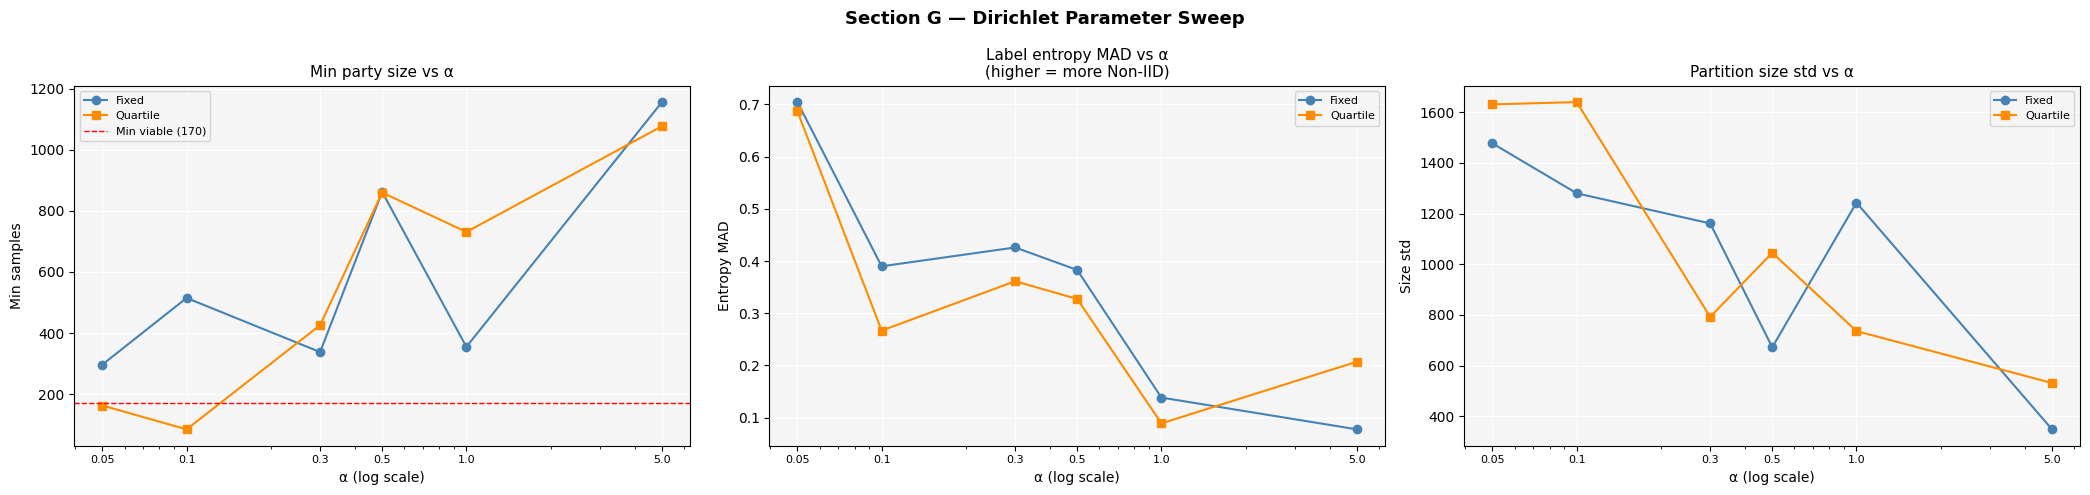

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(21, 5))
fig.suptitle('Section G — Dirichlet Parameter Sweep', fontsize=13, fontweight='bold')

styles = {'Fixed':    ('steelblue','o'), 'Quartile': ('darkorange','s')}
min_viable = max(50, len(df_meta) // N_PARTIES // 10)

for scheme_label, (color, marker) in styles.items():
    sub = dir_df[dir_df['Scheme'] == scheme_label]
    axes[0].plot(sub['α'], sub['Min size'], label=scheme_label, color=color, marker=marker)
    axes[1].plot(sub['α'], sub['Entropy MAD'], label=scheme_label, color=color, marker=marker)
    axes[2].plot(sub['α'], sub['Size std'], label=scheme_label, color=color, marker=marker)

axes[0].axhline(min_viable, color='red', linestyle='--', linewidth=1, label=f'Min viable ({min_viable})')
for ax, title, ylabel in zip(axes,
    ['Min party size vs α', 'Label entropy MAD vs α\n(higher = more Non-IID)', 'Partition size std vs α'],
    ['Min samples', 'Entropy MAD', 'Size std']):
    ax.set_xscale('log')
    ax.set_xticks(ALPHAS)
    ax.set_xticklabels([str(a) for a in ALPHAS], fontsize=8)
    ax.set_title(title)
    ax.set_xlabel('α (log scale)')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## Section H — Cutoff Selection Summary

In [12]:
def eval_scheme(df_in, tier_col_name, n_parties=6, alphas=(0.1, 0.5), seed=42):
    df_e = df_in.copy()
    df_e['tier'] = df_e[tier_col_name]
    cnts = df_e['tier'].value_counts().sort_index()
    global_ent = scipy_entropy(cnts.values)
    res = {'tier_balance': round(float(cnts.min()/cnts.max()), 3),
           'min_tier_count': int(cnts.min()),
           'global_entropy': round(float(global_ent), 4)}
    for alpha in alphas:
        try:
            parts = DirichletLabelPartitioner(
                n_partitions=n_parties, alpha=alpha, label_col='tier', seed=seed
            ).partition(df_e)
            sizes = np.array([len(p) for p in parts])
            ents  = np.array([
                scipy_entropy(p['tier'].value_counts().reindex(range(4), fill_value=0).values)
                for p in parts
            ])
            res[f'dir_α{alpha}_min_size']    = int(sizes.min())
            res[f'dir_α{alpha}_entropy_mad'] = round(float(np.mean(np.abs(ents - global_ent))), 4)
        except Exception:
            res[f'dir_α{alpha}_min_size']    = -1
            res[f'dir_α{alpha}_entropy_mad'] = float('nan')
    return res


rows_h = []
for scheme_label, tier_col_name in [
    ('Fixed (0/2/8/20%)', 'tier_fixed'),
    ('Quartile Q25/50/75', 'tier_quartile'),
    ('Hybrid (2%+tertiles)', 'tier_hybrid'),
]:
    row = {'Labeling scheme': scheme_label}
    row.update(eval_scheme(df_meta, tier_col_name))
    rows_h.append(row)

final_df = pd.DataFrame(rows_h).set_index('Labeling scheme')
print(final_df.to_string())

print('\nCramér\'s V (design ↔ tier):')
for scheme_label, tier_col_name in [
    ('Fixed', 'tier_fixed'), ('Quartile', 'tier_quartile'), ('Hybrid', 'tier_hybrid')
]:
    v = cramers_v(df_meta['design_name'], df_meta[tier_col_name])
    interp = ('weak' if v < 0.1 else 'moderate' if v < 0.3 else 'strong')
    print(f'  {scheme_label:<12s}: V={v:.4f}  [{interp}]')

# Auto-select best-balanced tier scheme for the partitioning sections below
balances = {col: df_meta[col].value_counts().pipe(lambda s: s.min()/s.max())
            for col in ['tier_fixed','tier_quartile','tier_hybrid']}
BEST_TIER_COL = max(balances, key=balances.get)
print(f'\nAuto-selected tier column for partitioning sections: {BEST_TIER_COL} '
      f'(balance={balances[BEST_TIER_COL]:.3f})')

                      tier_balance  min_tier_count  global_entropy  dir_α0.1_min_size  dir_α0.1_entropy_mad  dir_α0.5_min_size  dir_α0.5_entropy_mad
Labeling scheme                                                                                                                                     
Fixed (0/2/8/20%)            0.062             269          1.1121                515                0.3899                862                0.3829
Quartile Q25/50/75           1.000            2560          1.3863                 85                0.5408                860                0.6015
Hybrid (2%+tertiles)         0.079             269          1.1912                218                0.6567                138                0.3861

Cramér's V (design ↔ tier):
  Fixed       : V=0.1331  [moderate]
  Quartile    : V=0.1485  [moderate]
  Hybrid      : V=0.1533  [moderate]

Auto-selected tier column for partitioning sections: tier_quartile (balance=1.000)


In [13]:
fixed_balance = df_meta['tier_fixed'].value_counts().pipe(lambda s: s.min()/s.max())

print('=' * 70)
print('DATA-DRIVEN CUTOFF RECOMMENDATION')
print('=' * 70)
print()
if fixed_balance > 0.10:
    print('→ Fixed cutoffs are ACCEPTABLE (balance > 10%).\n  Proceed with fixed for interpretability.')
else:
    print('→ Fixed cutoffs are IMBALANCED. Use Quartile or Hybrid instead.')
print()
if abs(r) > 0.90:
    print('→ Hotspot count is REDUNDANT. Use violation_rate alone.')
else:
    print('→ Hotspot count adds information. Option D is worth exploring.')
v_fixed = cramers_v(df_meta['design_name'], df_meta['tier_fixed'])
print()
if v_fixed > 0.3:
    print(f'→ V={v_fixed:.3f}: STRONG design↔tier correlation. Declare in report.')
elif v_fixed > 0.1:
    print(f'→ V={v_fixed:.3f}: MODERATE correlation. Mention in methodology.')
else:
    print(f'→ V={v_fixed:.3f}: WEAK correlation. Label skew is independent of design.')
print('=' * 70)

DATA-DRIVEN CUTOFF RECOMMENDATION

→ Fixed cutoffs are IMBALANCED. Use Quartile or Hybrid instead.

→ Hotspot count is REDUNDANT. Use violation_rate alone.

→ V=0.133: MODERATE correlation. Mention in methodology.


---
## Section I — Partitioning Validation: Helpers and Setup

The following sections apply and visualise all **label/quantity-based** NIID-Bench strategies  
using the data-driven tier assignment selected above.  
Feature-based strategies (Noise, Synthetic grid) are covered in `features_analysis.ipynb`.

| Strategy | Skew type |
|----------|-----------|
| 1 — IID | None (baseline) |
| 2 — Quantity-label (#C=k) | Label distribution |
| 3 — Dirichlet-label (α) | Label distribution |
| 6 — Quantity skew (α) | Quantity |

In [14]:
from partitioning import (
    IIDPartitioner,
    QuantityLabelPartitioner,
    DirichletLabelPartitioner,
    NoiseFeaturePartitioner,
    SyntheticFeaturePartitioner,
    QuantitySkewPartitioner,
)

# Working DataFrame: use the best-balanced tier column as 'tier'
df = df_meta.copy()
df['tier'] = df[BEST_TIER_COL]
TIER_NAMES = assigner_fixed.TIER_NAMES   # {0:'clean', 1:'low', 2:'medium', 3:'high'}
N_TIERS    = 4
ALL_TIERS  = list(range(N_TIERS))

_TAB10 = mcm.get_cmap('tab10')
_SET2  = mcm.get_cmap('Set2')
PARTY_COLORS = [_TAB10(i / 10) for i in range(10)]
TIER_COLORS  = ['#4caf50','#ff9800','#f44336','#9c27b0']


def plot_sizes(partitions, ax, title='Sizes'):
    sizes = [len(p) for p in partitions]
    bars  = ax.bar(range(len(partitions)), sizes,
                   color=PARTY_COLORS[:len(partitions)], alpha=0.85, edgecolor='white')
    ax.set_xticks(range(len(partitions)))
    ax.set_xticklabels([f'P{i}' for i in range(len(partitions))], fontsize=8)
    ax.set_title(title)
    ax.set_ylabel('Samples')
    for bar, s in zip(bars, sizes):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                str(s), ha='center', fontsize=7)


def plot_tier_dist(partitions, ax, title='Tier distribution'):
    bottom = np.zeros(len(partitions))
    counts = pd.DataFrame({
        f'P{i}': p['tier'].value_counts().reindex(ALL_TIERS, fill_value=0)
        for i, p in enumerate(partitions)
    }).T
    for t in ALL_TIERS:
        vals = counts[t].values if t in counts.columns else np.zeros(len(partitions))
        ax.bar(range(len(partitions)), vals, bottom=bottom,
               color=TIER_COLORS[t], label=TIER_NAMES.get(t,str(t)), alpha=0.87)
        bottom += vals
    ax.set_xticks(range(len(partitions)))
    ax.set_xticklabels([f'P{i}' for i in range(len(partitions))], fontsize=8)
    ax.set_title(title)
    ax.set_ylabel('Samples')
    ax.legend(title='tier', fontsize=7, bbox_to_anchor=(1.01,1), loc='upper left')


def plot_feature_box(partitions, col, ax, title=None):
    data = [p[col].dropna().values for p in partitions]
    bp = ax.boxplot(data, patch_artist=True, notch=False,
                    medianprops={'color':'black','linewidth':1.4},
                    flierprops={'marker':'.','markersize':2,'alpha':0.3})
    for patch, color in zip(bp['boxes'], PARTY_COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.72)
    ax.set_xticks(range(1, len(partitions)+1))
    ax.set_xticklabels([f'P{i}' for i in range(len(partitions))], fontsize=8)
    ax.set_title(title or col)
    ax.set_ylabel(col)


def show_summary(partitions, method_name, feat_cols=('utilization','clock_ns')):
    fig, axes = plt.subplots(1, 4, figsize=(24, 5))
    fig.suptitle(method_name, fontsize=13, fontweight='bold')
    plot_sizes(partitions, axes[0])
    plot_tier_dist(partitions, axes[1])
    for ax, col in zip(axes[2:], feat_cols):
        if col in partitions[0].columns:
            plot_feature_box(partitions, col, ax, title=f'{col} per party')
    plt.tight_layout()
    plt.show()


def tier_entropy_mad(partitions):
    glob_cnts = pd.concat(partitions)['tier'].value_counts().reindex(ALL_TIERS, fill_value=0).values
    glob_ent  = scipy_entropy(glob_cnts)
    ents = [
        scipy_entropy(p['tier'].value_counts().reindex(ALL_TIERS, fill_value=0).values)
        for p in partitions
    ]
    return float(np.mean(np.abs(np.array(ents) - glob_ent)))


print(f'Working tier column : {BEST_TIER_COL}')
print(f'Tier distribution   : {df["tier"].value_counts().sort_index().to_dict()}')
print(f'N_PARTIES           : {N_PARTIES}')
print('Helper functions ready.')

Working tier column : tier_quartile
Tier distribution   : {0: 2561, 1: 2560, 2: 2560, 3: 2561}
N_PARTIES           : 6
Helper functions ready.


---
## Section J — Strategy 1: IID Partitioning (Label Baseline)

Each party receives a stratified share of all tiers.  
P(tier | party i) ≈ P(tier) for all i — no label skew.

IID sizes:            [1828, 1774, 1728, 1686, 1641, 1585]
IID label entropy MAD:0.0009  (should be ≈ 0)


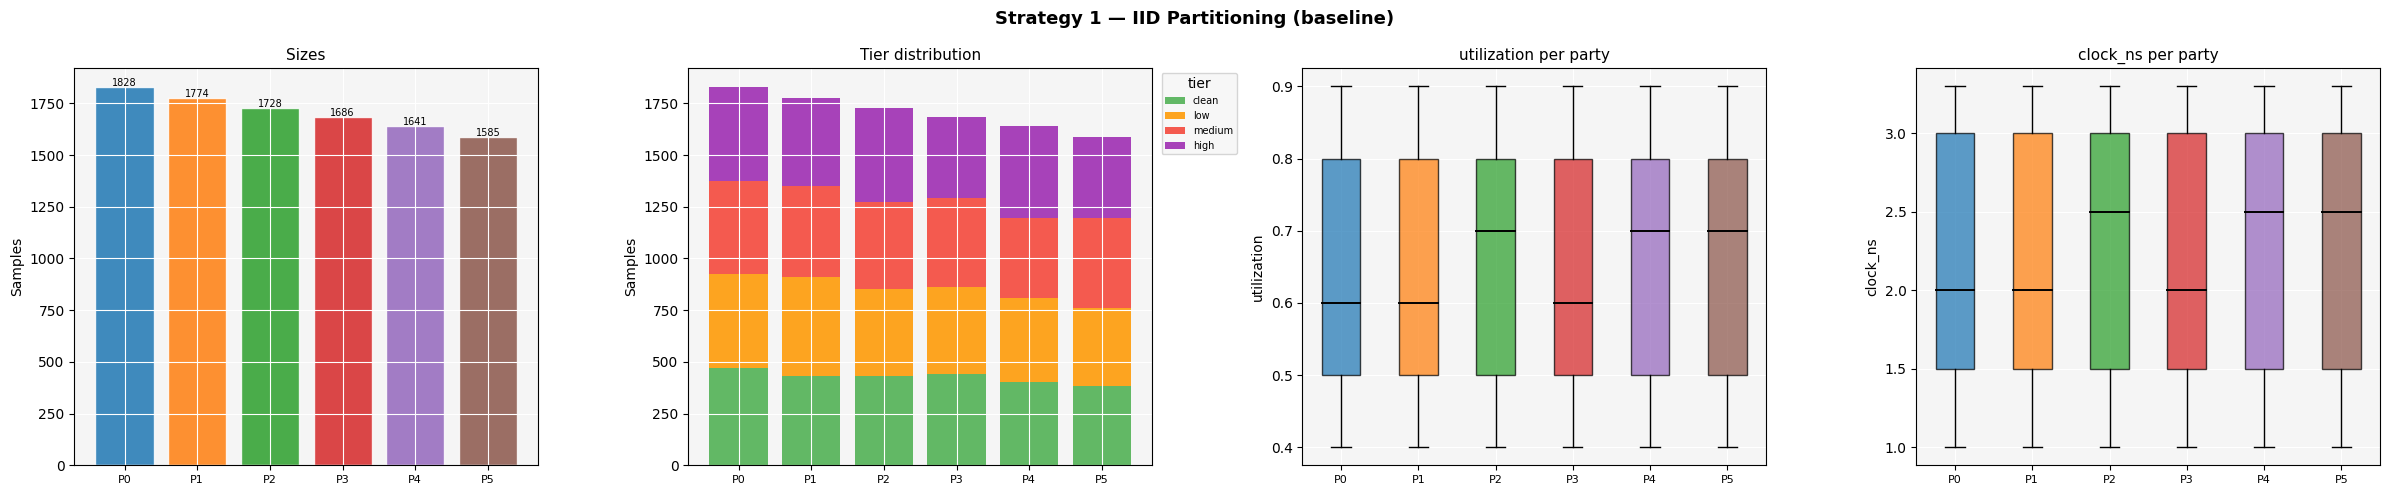

In [15]:
iid_parts = IIDPartitioner(n_partitions=N_PARTIES, seed=42).partition(df)

iid_ent_mad = tier_entropy_mad(iid_parts)
print(f'IID sizes:            {[len(p) for p in iid_parts]}')
print(f'IID label entropy MAD:{iid_ent_mad:.4f}  (should be ≈ 0)')

show_summary(iid_parts, 'Strategy 1 — IID Partitioning (baseline)')

---
## Section K — Strategy 2: Quantity-Based Label Imbalance (#C = k)

Each party is assigned exactly **k** out of the 4 tiers.  
Lower k → stronger label skew.  
We compare k = 1 (extreme), k = 2 (strong), k = 3 (mild).

k=1  sizes=[2561, 1280, 1280, 2561, 1280, 1280]  entropy_MAD=1.3863


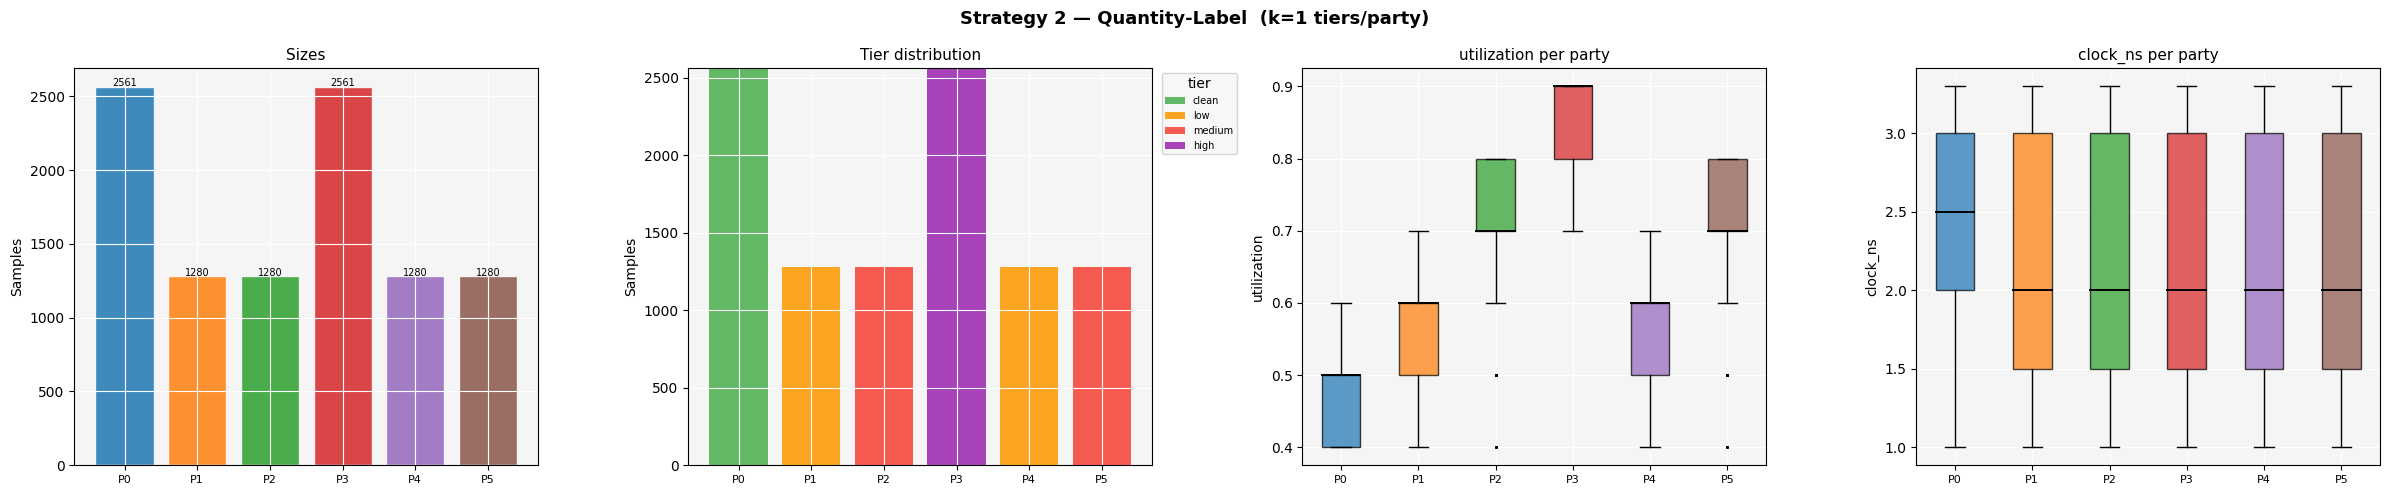

k=2  sizes=[1708, 1708, 1707, 1707, 1706, 1706]  entropy_MAD=0.6931


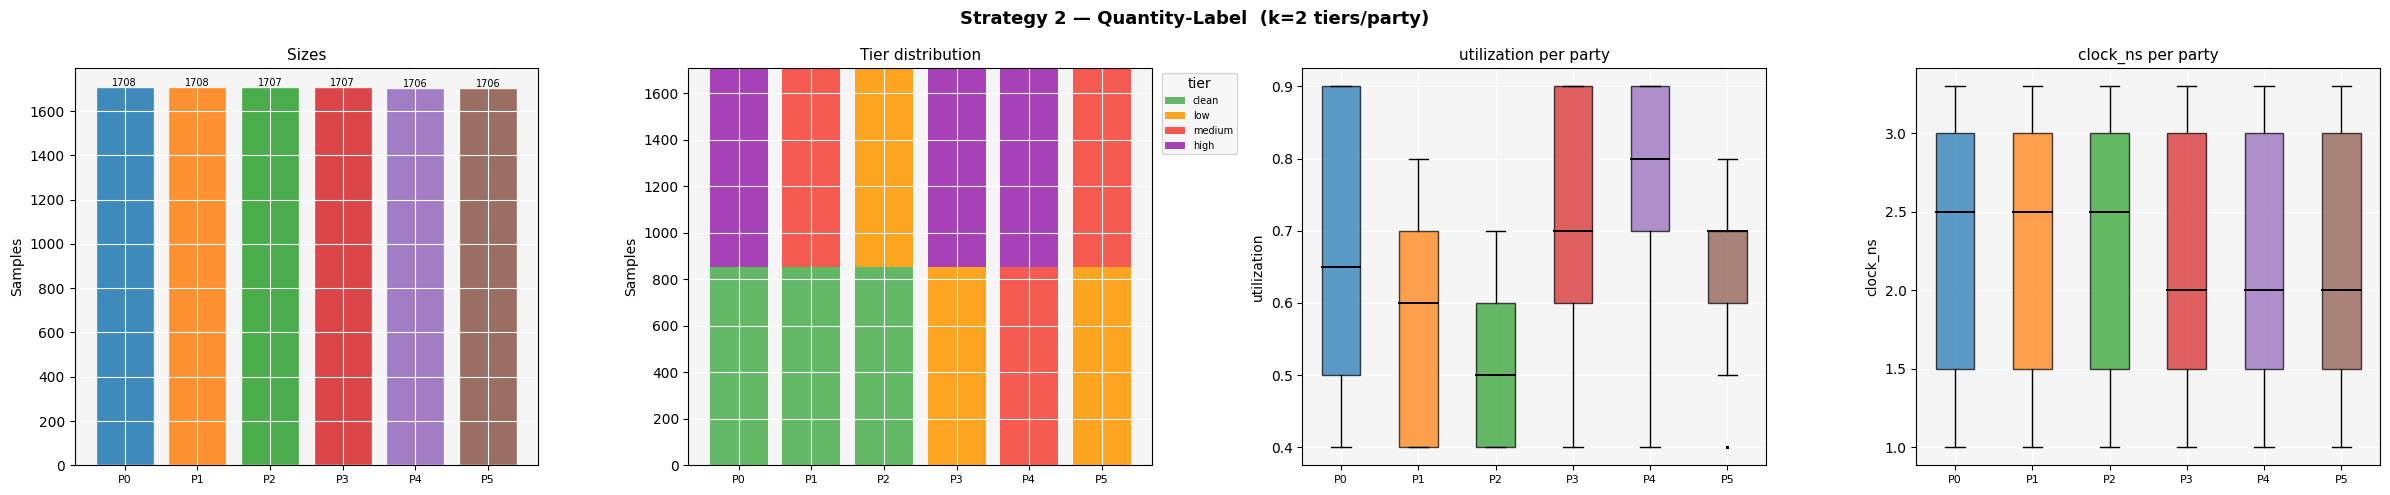

k=3  sizes=[1794, 1664, 1664, 1792, 1664, 1664]  entropy_MAD=0.2933


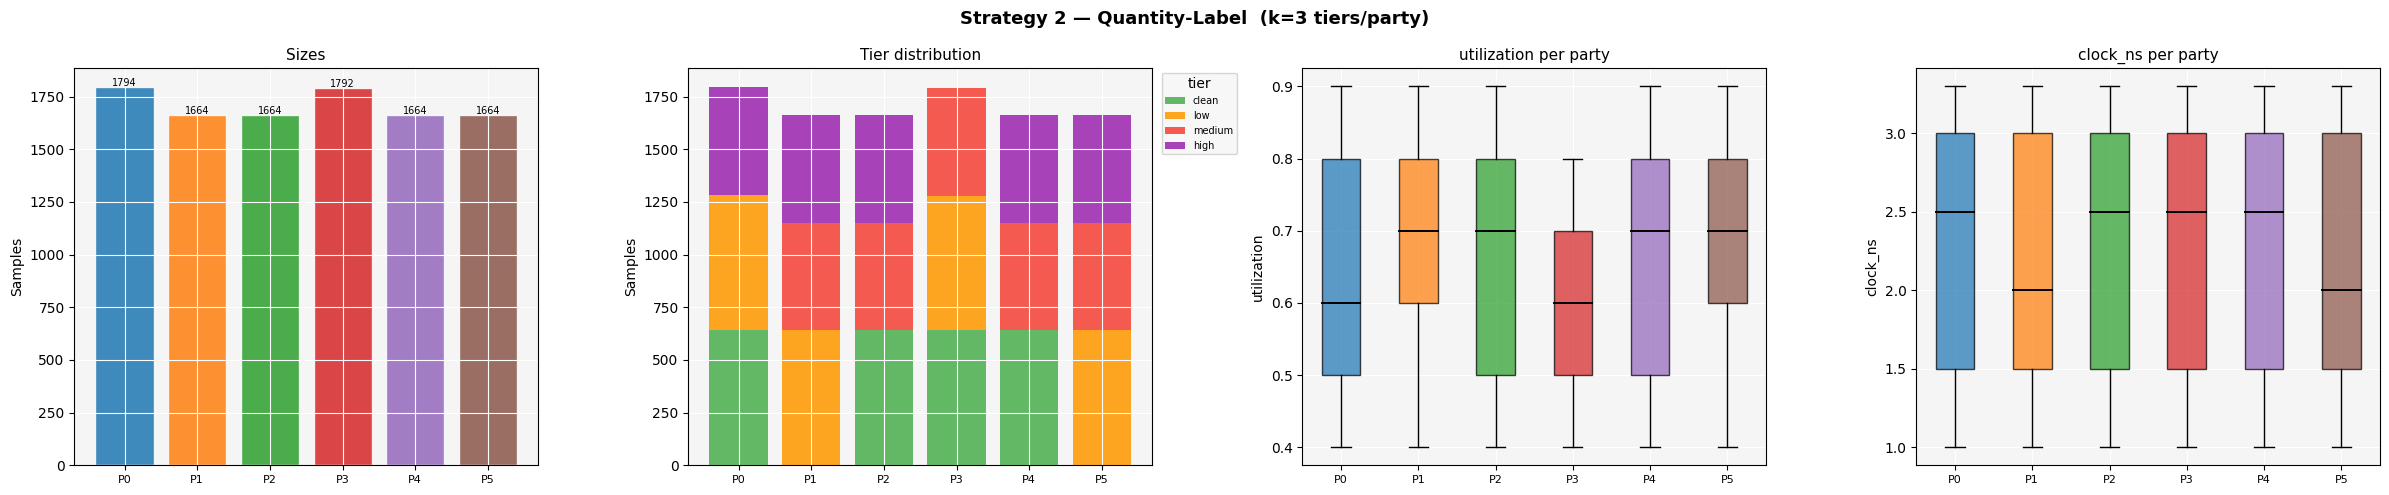


Tiers owned per party (k=2):
  Party 0: tiers=[0, 3] ['clean', 'high']  (1708 samples)
  Party 1: tiers=[0, 2] ['clean', 'medium']  (1708 samples)
  Party 2: tiers=[0, 1] ['clean', 'low']  (1707 samples)
  Party 3: tiers=[1, 3] ['low', 'high']  (1707 samples)
  Party 4: tiers=[2, 3] ['medium', 'high']  (1706 samples)
  Party 5: tiers=[1, 2] ['low', 'medium']  (1706 samples)


In [16]:
for k in [1, 2, 3]:
    parts = QuantityLabelPartitioner(
        n_partitions=N_PARTIES, n_labels_per_party=k, label_col='tier', seed=42
    ).partition(df)
    ent_mad = tier_entropy_mad(parts)
    print(f'k={k}  sizes={[len(p) for p in parts]}  entropy_MAD={ent_mad:.4f}')
    show_summary(parts, f'Strategy 2 — Quantity-Label  (k={k} tiers/party)')

# Show which tiers each party holds for k=2
k2_parts = QuantityLabelPartitioner(
    n_partitions=N_PARTIES, n_labels_per_party=2, label_col='tier', seed=42
).partition(df)
print('\nTiers owned per party (k=2):')
for i, p in enumerate(k2_parts):
    owned = sorted(p['tier'].unique())
    names = [TIER_NAMES.get(t,str(t)) for t in owned]
    print(f'  Party {i}: tiers={owned} {names}  ({len(p)} samples)')

---
## Section L — Strategy 3: Distribution-Based Label Imbalance (Dirichlet α)

For each tier, a Dirichlet(α) draw controls how samples are split among parties.  
α → 0: near-exclusive ownership per tier.  
α → ∞: IID.

α=0.1  sizes=[2553, 3181, 160, 149, 85, 4114]  entropy_MAD=0.5408


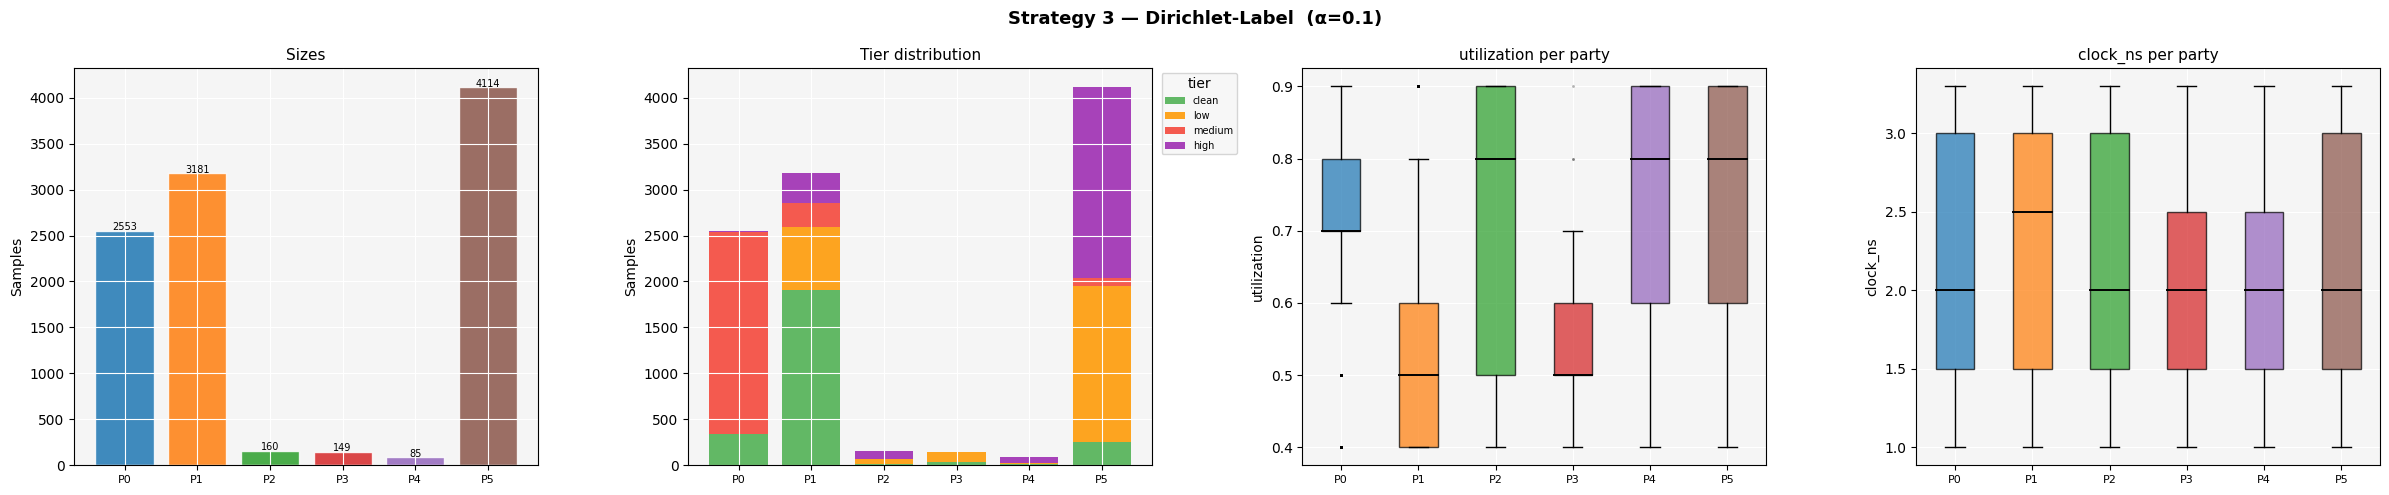

α=0.5  sizes=[1018, 1204, 948, 3664, 2548, 860]  entropy_MAD=0.6015


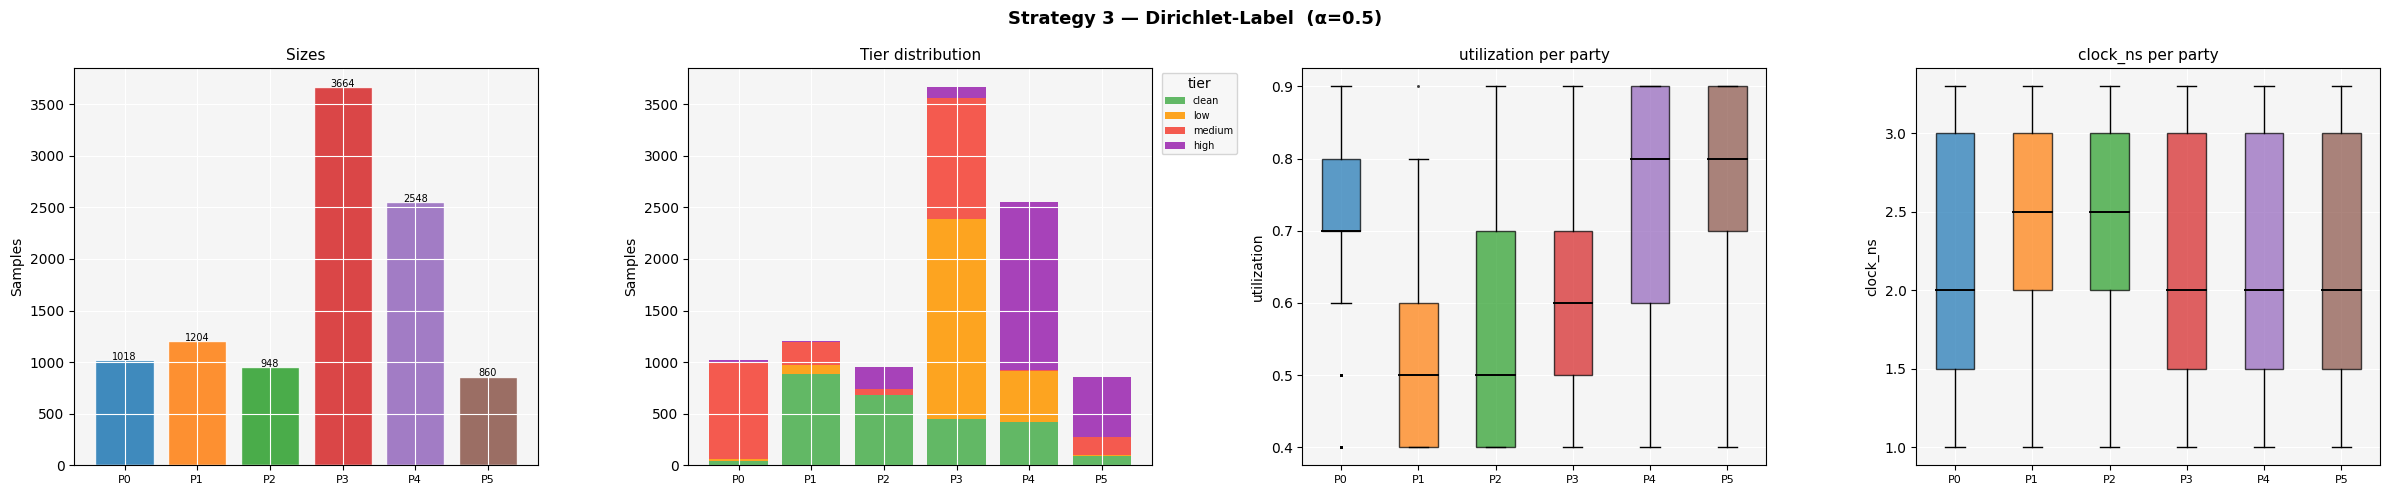

α=5.0  sizes=[2053, 1897, 1372, 1077, 2606, 1237]  entropy_MAD=0.0671


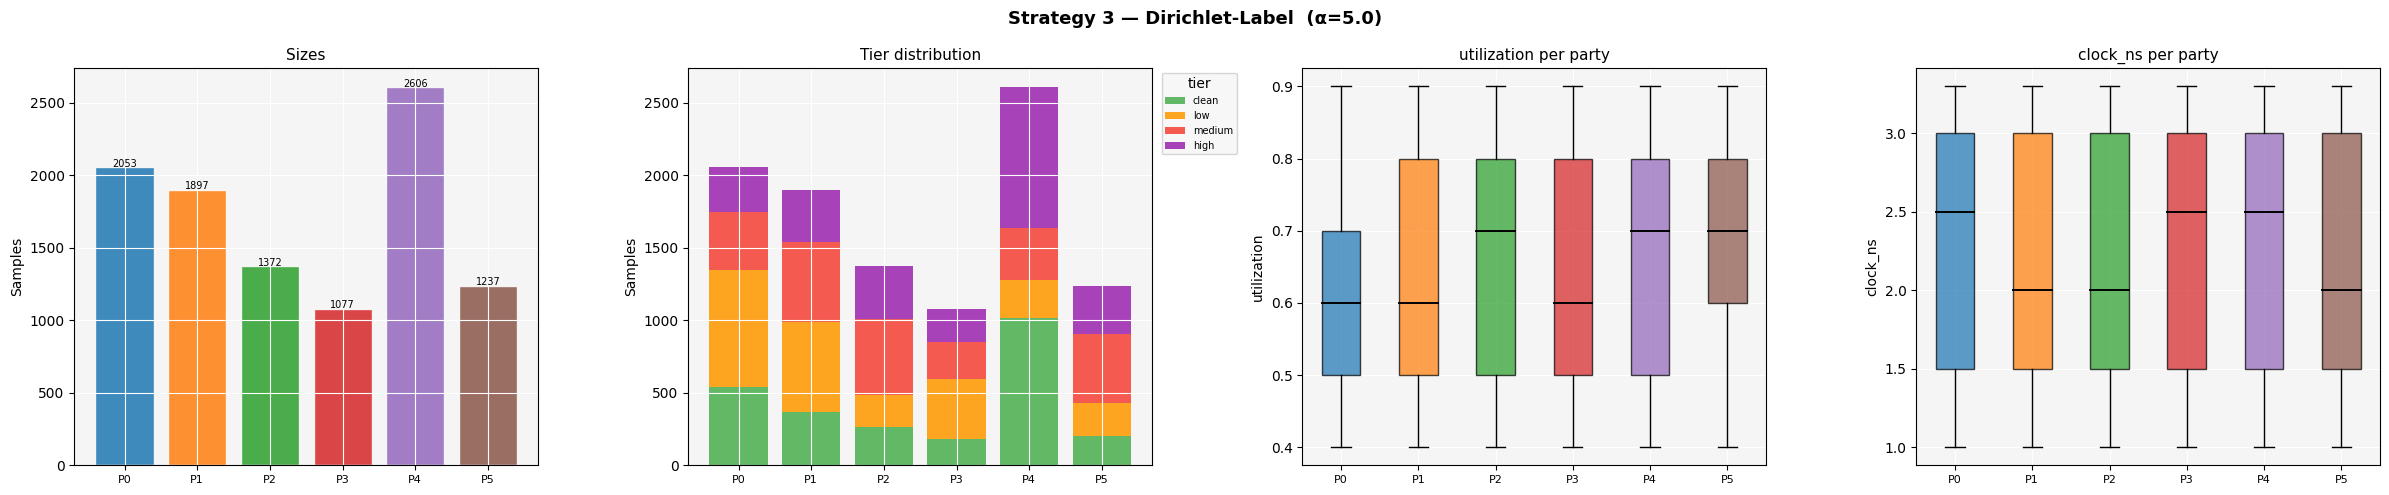

In [17]:
ALPHAS_VIZ = [0.1, 0.5, 5.0]

for alpha in ALPHAS_VIZ:
    parts = DirichletLabelPartitioner(
        n_partitions=N_PARTIES, alpha=alpha, label_col='tier', seed=42
    ).partition(df)
    ent_mad = tier_entropy_mad(parts)
    print(f'α={alpha}  sizes={[len(p) for p in parts]}  entropy_MAD={ent_mad:.4f}')
    show_summary(parts, f'Strategy 3 — Dirichlet-Label  (α={alpha})')

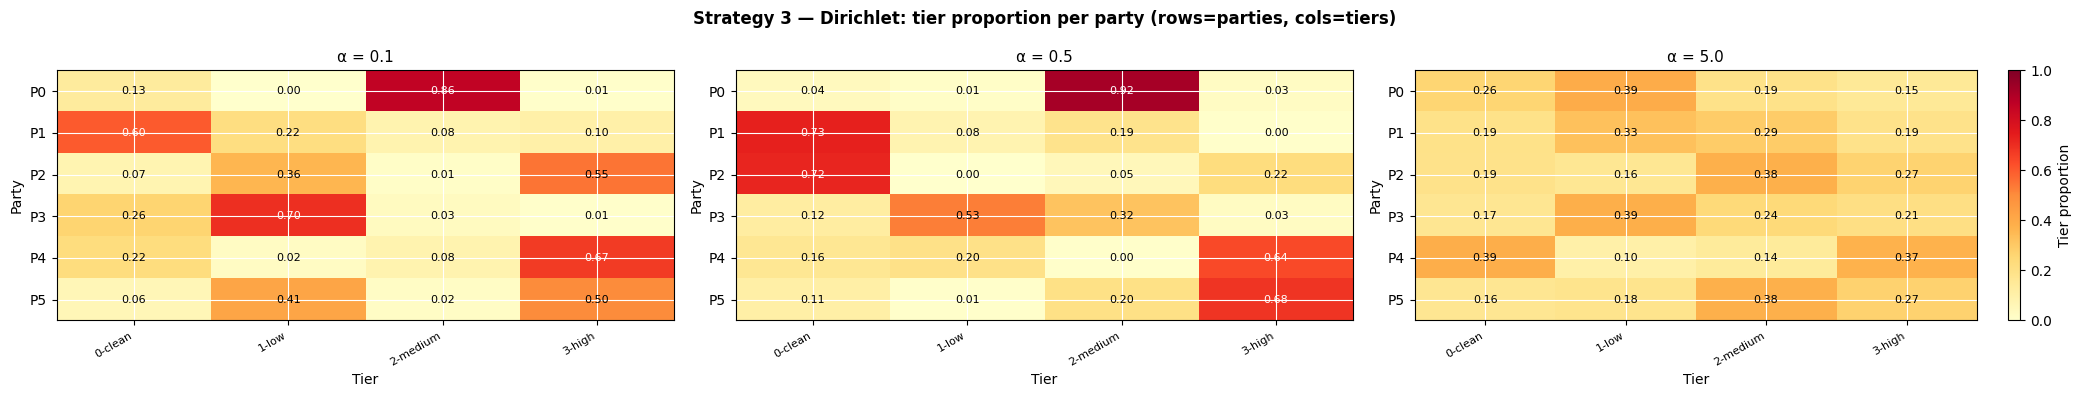

In [18]:
# Heatmap: tier proportion per party across alpha values
fig, axes = plt.subplots(1, 3, figsize=(21, 4))
fig.suptitle('Strategy 3 — Dirichlet: tier proportion per party (rows=parties, cols=tiers)',
             fontsize=12, fontweight='bold')

tier_labels = [f'{t}-{TIER_NAMES.get(t,"?")}' for t in ALL_TIERS]

for ax, alpha in zip(axes, ALPHAS_VIZ):
    parts = DirichletLabelPartitioner(
        n_partitions=N_PARTIES, alpha=alpha, label_col='tier', seed=42
    ).partition(df)
    mat = np.array([
        p['tier'].value_counts().reindex(ALL_TIERS, fill_value=0).values / max(len(p),1)
        for p in parts
    ])
    im = ax.imshow(mat, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
    for r in range(N_PARTIES):
        for c in range(N_TIERS):
            val = mat[r, c]
            ax.text(c, r, f'{val:.2f}', ha='center', va='center',
                    fontsize=8, color='white' if val > 0.55 else 'black')
    ax.set_xticks(range(N_TIERS))
    ax.set_xticklabels(tier_labels, rotation=30, ha='right', fontsize=8)
    ax.set_yticks(range(N_PARTIES))
    ax.set_yticklabels([f'P{i}' for i in range(N_PARTIES)])
    ax.set_title(f'α = {alpha}')
    ax.set_xlabel('Tier')
    ax.set_ylabel('Party')

plt.colorbar(im, ax=axes[-1], fraction=0.04, label='Tier proportion')
plt.tight_layout()
plt.show()

---
## Section M — Strategy 6: Quantity Skew (Dirichlet on sample count)

The total dataset is randomly split with a Dirichlet(α) draw on the *quantity* each party receives.  
Label composition within each party mirrors the global distribution — only *how much* data varies.  
Low α → extreme size imbalance.

α=0.1  sizes=[84, 2, 19, 1042, 433, 8662]  entropy_MAD=0.1240


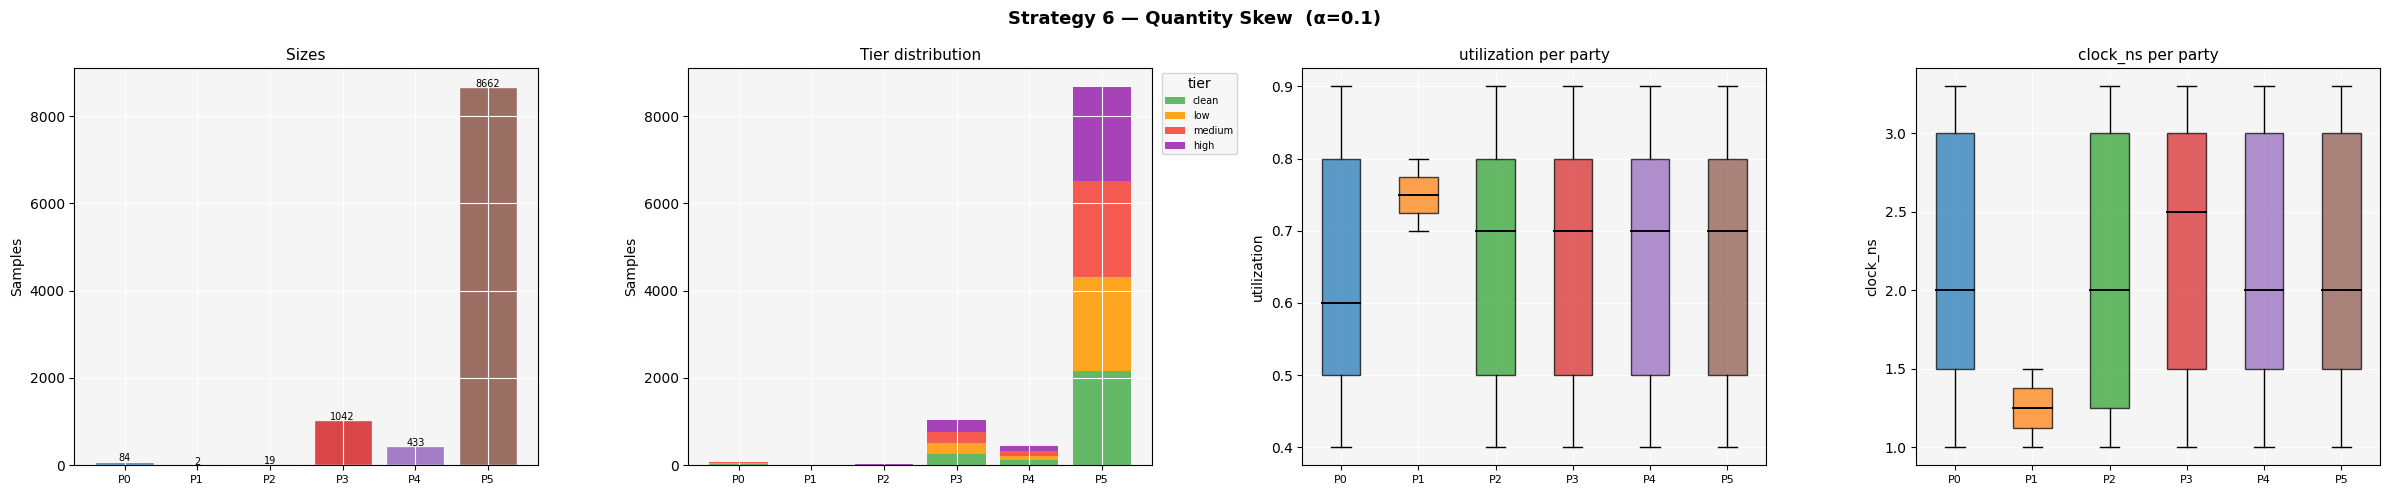

α=0.5  sizes=[2743, 4369, 30, 2577, 55, 468]  entropy_MAD=0.0066


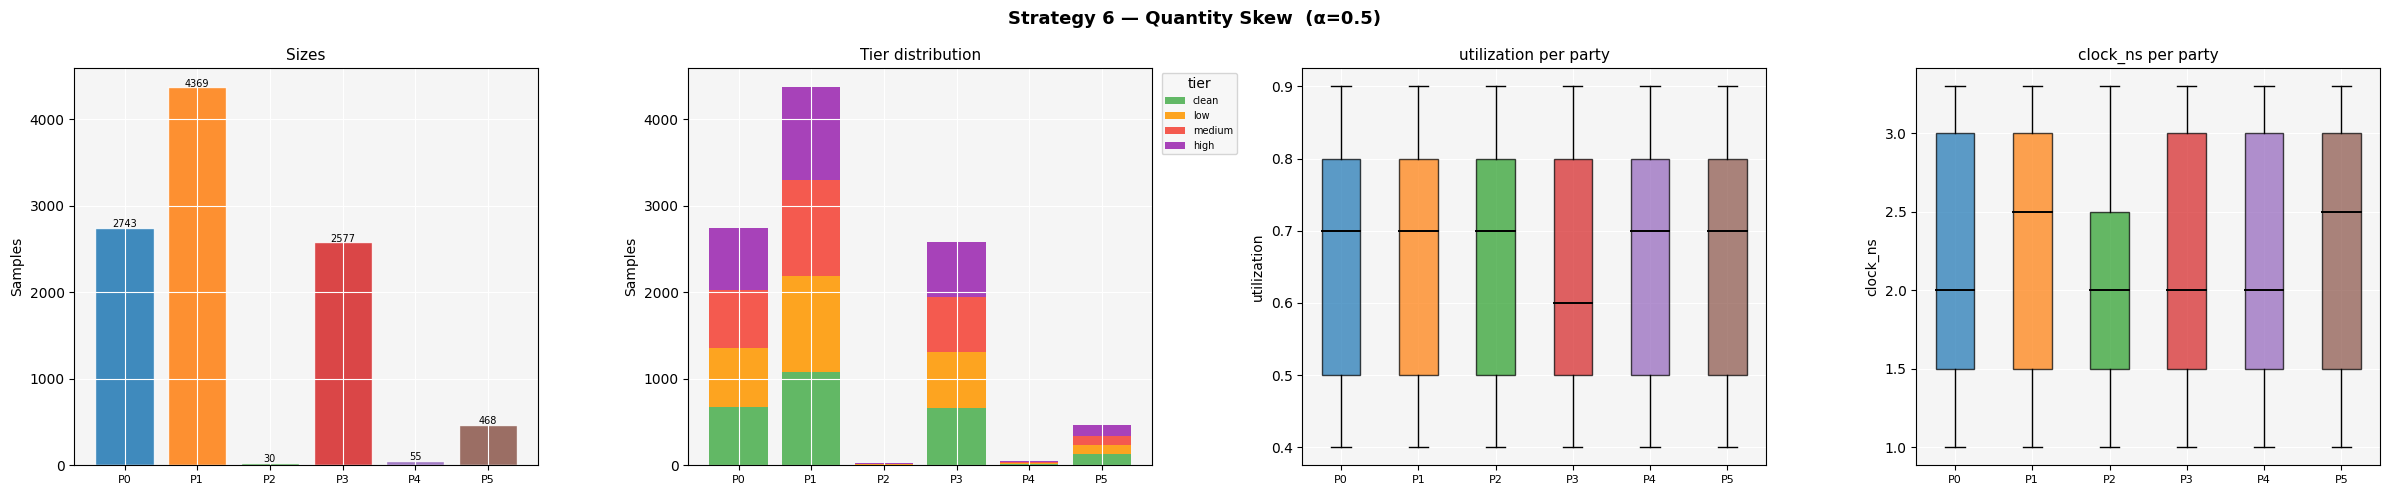

α=5.0  sizes=[1659, 2008, 1532, 1434, 2119, 1490]  entropy_MAD=0.0005


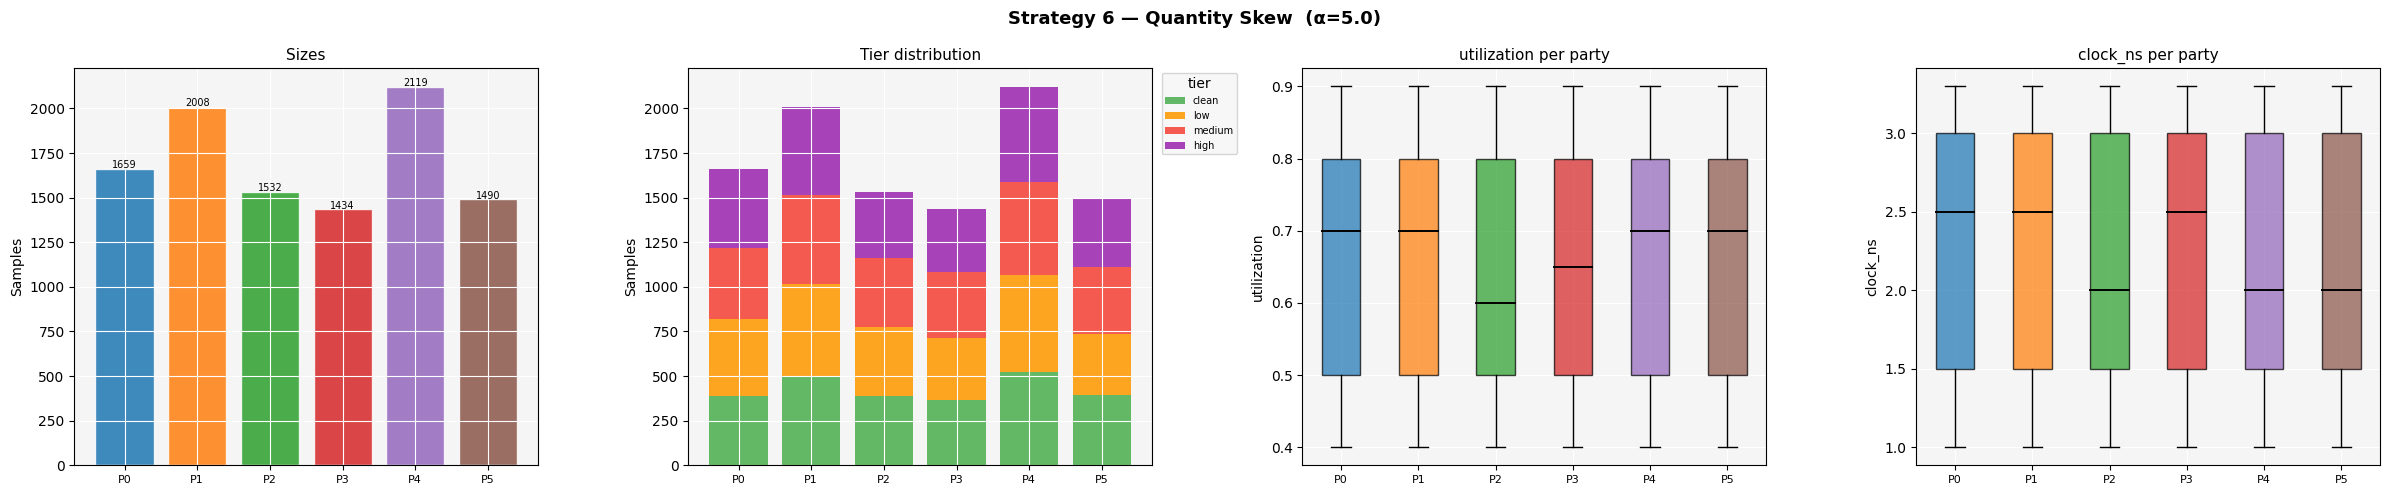

In [19]:
for alpha in ALPHAS_VIZ:
    parts = QuantitySkewPartitioner(
        n_partitions=N_PARTIES, alpha=alpha, seed=42
    ).partition(df)
    ent_mad = tier_entropy_mad(parts)
    print(f'α={alpha}  sizes={[len(p) for p in parts]}  entropy_MAD={ent_mad:.4f}')
    show_summary(parts, f'Strategy 6 — Quantity Skew  (α={alpha})')

---
## Section N — Cross-Strategy Comparison (All 6 Strategies)

Compare all strategies on two orthogonal axes:
- **Size std**: how unequal are the party sizes? (quantity skew)
- **Label entropy MAD**: how different are the per-party tier distributions? (label skew)

Strategies 4 (Noise) and 5 (Synthetic) are included as feature-distribution references  
from `features_analysis.ipynb` — their label distribution is IID by construction (entropy MAD ≈ 0).

In [20]:
def summary_row(name, parts):
    sizes = np.array([len(p) for p in parts])
    return {
        'Strategy': name,
        'Sizes': sizes.tolist(),
        'Size std': round(float(sizes.std()), 1),
        'Min size': int(sizes.min()),
        'Max size': int(sizes.max()),
        'Label entropy MAD': round(tier_entropy_mad(parts), 4),
    }


rows_n = [
    summary_row('IID',
        IIDPartitioner(N_PARTIES, seed=42).partition(df)),

    summary_row('Qty-Label k=1',
        QuantityLabelPartitioner(N_PARTIES, n_labels_per_party=1, label_col='tier', seed=42).partition(df)),
    summary_row('Qty-Label k=2',
        QuantityLabelPartitioner(N_PARTIES, n_labels_per_party=2, label_col='tier', seed=42).partition(df)),
    summary_row('Qty-Label k=3',
        QuantityLabelPartitioner(N_PARTIES, n_labels_per_party=3, label_col='tier', seed=42).partition(df)),

    summary_row('Dir-Label α=0.1',
        DirichletLabelPartitioner(N_PARTIES, alpha=0.1, label_col='tier', seed=42).partition(df)),
    summary_row('Dir-Label α=0.5',
        DirichletLabelPartitioner(N_PARTIES, alpha=0.5, label_col='tier', seed=42).partition(df)),
    summary_row('Dir-Label α=5.0',
        DirichletLabelPartitioner(N_PARTIES, alpha=5.0, label_col='tier', seed=42).partition(df)),

    # Strategies 4 & 5: feature skew only — label entropy MAD ≈ 0 by construction
    summary_row('Noise-Feature',
        NoiseFeaturePartitioner(N_PARTIES, seed=42).partition(df)),
    summary_row('Synthetic-Feature',
        SyntheticFeaturePartitioner(N_PARTIES, seed=42).partition(df)),

    summary_row('Qty-Skew α=0.1',
        QuantitySkewPartitioner(N_PARTIES, alpha=0.1, seed=42).partition(df)),
    summary_row('Qty-Skew α=0.5',
        QuantitySkewPartitioner(N_PARTIES, alpha=0.5, seed=42).partition(df)),
    summary_row('Qty-Skew α=5.0',
        QuantitySkewPartitioner(N_PARTIES, alpha=5.0, seed=42).partition(df)),
]

summary_df = pd.DataFrame(rows_n).set_index('Strategy')
print(summary_df[['Size std','Min size','Max size','Label entropy MAD']].to_string())

                   Size std  Min size  Max size  Label entropy MAD
Strategy                                                          
IID                    80.9      1585      1828             0.0009
Qty-Label k=1         603.9      1280      2561             1.3863
Qty-Label k=2           0.8      1706      1708             0.6931
Qty-Label k=3          60.8      1664      1794             0.2933
Dir-Label α=0.1      1639.8        85      4114             0.5408
Dir-Label α=0.5      1045.5       860      3664             0.6015
Dir-Label α=5.0       531.4      1077      2606             0.0671
Noise-Feature          80.9      1585      1828             0.0009
Synthetic-Feature     707.7       816      2622             0.7775
Qty-Skew α=0.1       3131.2         2      8662             0.1240
Qty-Skew α=0.5       1632.6        30      4369             0.0066
Qty-Skew α=5.0        263.0      1434      2119             0.0005


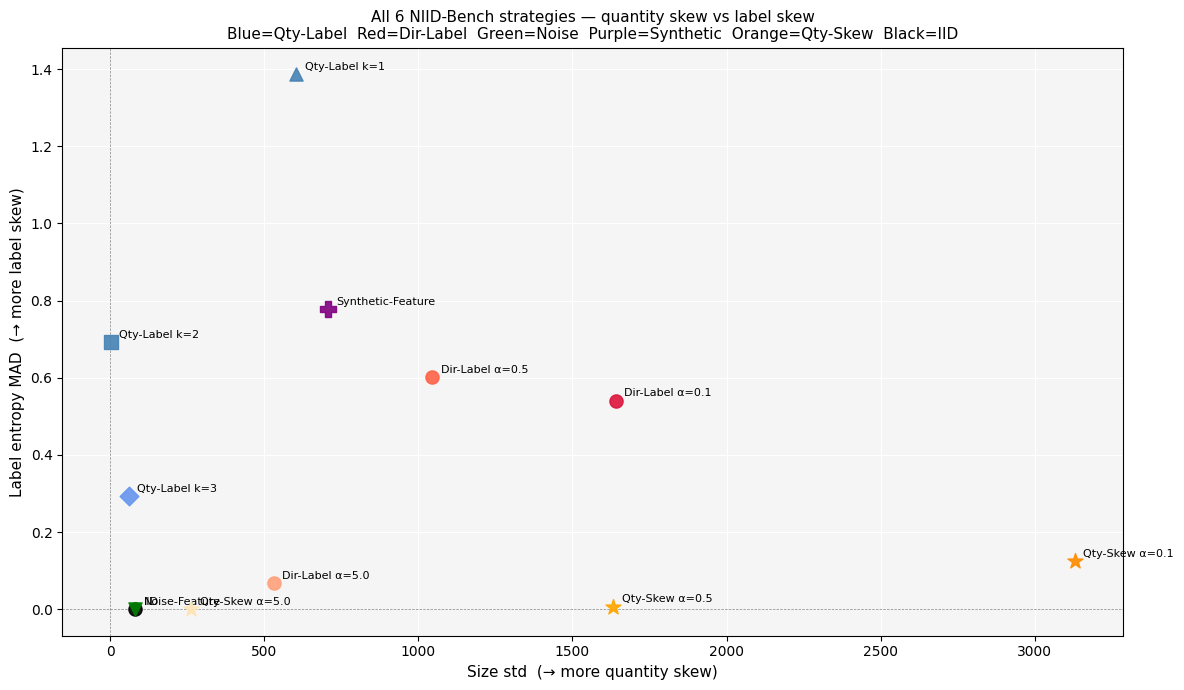

In [21]:
# Scatter: Size std vs Label entropy MAD
STRATEGY_STYLE = {
    'IID':              ('black',     'o'),
    'Qty-Label k=1':    ('steelblue', '^'),
    'Qty-Label k=2':    ('steelblue', 's'),
    'Qty-Label k=3':    ('cornflowerblue','D'),
    'Dir-Label α=0.1':  ('crimson',   'o'),
    'Dir-Label α=0.5':  ('tomato',    'o'),
    'Dir-Label α=5.0':  ('lightsalmon','o'),
    'Noise-Feature':    ('green',     'v'),
    'Synthetic-Feature':('purple',    'P'),
    'Qty-Skew α=0.1':   ('darkorange','*'),
    'Qty-Skew α=0.5':   ('orange',    '*'),
    'Qty-Skew α=5.0':   ('moccasin',  '*'),
}

fig, ax = plt.subplots(figsize=(12, 7))
for strategy, row in summary_df.iterrows():
    color, marker = STRATEGY_STYLE.get(strategy, ('grey', 'o'))
    ax.scatter(row['Size std'], row['Label entropy MAD'],
               s=130 if marker in ('*','P') else 90,
               color=color, marker=marker, zorder=5, alpha=0.9)
    ax.annotate(strategy, (row['Size std'], row['Label entropy MAD']),
                textcoords='offset points', xytext=(6, 3), fontsize=8)

ax.set_xlabel('Size std  (→ more quantity skew)', fontsize=11)
ax.set_ylabel('Label entropy MAD  (→ more label skew)', fontsize=11)
ax.set_title(
    'All 6 NIID-Bench strategies — quantity skew vs label skew\n'
    'Blue=Qty-Label  Red=Dir-Label  Green=Noise  Purple=Synthetic  Orange=Qty-Skew  Black=IID',
    fontsize=11
)
ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')
plt.tight_layout()
plt.show()

In [22]:
# Final comparison table with interpretation column
def interpret_row(row):
    label_skew = row['Label entropy MAD']
    qty_skew   = row['Size std']
    if label_skew < 0.02 and qty_skew < 200:
        return 'IID baseline'
    if label_skew > 0.30:
        return 'Very high label skew'
    if label_skew > 0.10:
        return 'High label skew'
    if qty_skew > 2000:
        return 'Very high quantity skew'
    if qty_skew > 800:
        return 'High quantity skew'
    return 'Moderate skew'


summary_df['Interpretation'] = summary_df.apply(interpret_row, axis=1)
print('\n=== FINAL CROSS-STRATEGY COMPARISON ===')
print(summary_df[['Size std','Min size','Max size','Label entropy MAD','Interpretation']].to_string())

print()
print('Recommendation:')
print('  For NIID-Bench label skew experiments:')
print('    → Start with Dir-Label α=0.5 (moderate, comparable across datasets)')
print('    → Add Qty-Label k=2 for the NIID-Bench #C=k strict variant')
print('    → Use α=0.1 only if very strong label Non-IID is needed')
print('  For quantity skew experiments:')
print('    → Qty-Skew α=0.5 provides meaningful size imbalance without data starvation')
print('  For feature skew: see features_analysis.ipynb')


=== FINAL CROSS-STRATEGY COMPARISON ===
                   Size std  Min size  Max size  Label entropy MAD        Interpretation
Strategy                                                                                
IID                    80.9      1585      1828             0.0009          IID baseline
Qty-Label k=1         603.9      1280      2561             1.3863  Very high label skew
Qty-Label k=2           0.8      1706      1708             0.6931  Very high label skew
Qty-Label k=3          60.8      1664      1794             0.2933       High label skew
Dir-Label α=0.1      1639.8        85      4114             0.5408  Very high label skew
Dir-Label α=0.5      1045.5       860      3664             0.6015  Very high label skew
Dir-Label α=5.0       531.4      1077      2606             0.0671         Moderate skew
Noise-Feature          80.9      1585      1828             0.0009          IID baseline
Synthetic-Feature     707.7       816      2622             0.7775  V